In [1]:
import re
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
from matplotlib import lines

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [2]:
from pathlib import Path
ROOT = Path('..')
path = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
raw = pd.read_csv(path, low_memory=False)
df = raw.query('2014 <= year <= 2025').copy()
text_cols = ['overview', 'strengths', 'weaknesses']
df[text_cols] = df[text_cols].fillna('')
df['scouting_text'] = (
    df[text_cols].agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
numeric_cols = ['grade']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Pos_Group'] = df['Pos_Group'].fillna('UNKNOWN')
df['is_drafted'] = df['is_drafted'].where(df.year <= 2021)
df = df.loc[(df['grade'] > 0) & (df['scouting_text'].str.strip() != '')].copy()

In [3]:
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide', 'pass',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
}
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]
_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS
_lemmatizer = WordNetLemmatizer()

def nfl_preprocess_no_stitch(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-–—]', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in NFL_STOPWORDS and len(t) > 1]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

_tag_prefix = {'overview': 'ovr', 'strengths': 'str', 'weaknesses': 'wkn'}
for col, prefix in _tag_prefix.items():
    df[f'{col}_clean'] = df[col].apply(nfl_preprocess_no_stitch)

In [4]:
# ── Section-tagged token representation ──────────────────────────────────────
# Instead of "OVR: token1 token2 STR: token3 token4" (cross-boundary bigrams),
# prefix every token with its section: "ovr_token1 ovr_token2 str_token3 str_token4"
#
# Benefits:
#   - No cross-section boundary bigrams by construction
#   - Bigrams stay within sections: "str_quick str_off_snap"
#   - Every feature is directly interpretable: ovr_* vs str_* vs wkn_*
#   - Can analyse which section drives predictions for each player/position

def build_section_tagged(row):
    parts = []
    for col, prefix in _tag_prefix.items():
        clean = str(row[f'{col}_clean']).strip()
        if clean:
            tagged = [f"{prefix}_{tok}" for tok in clean.split()]
            parts.extend(tagged)
    return ' '.join(parts)

df['scouting_text_tagged'] = df.apply(build_section_tagged, axis=1)
df = df.loc[df['scouting_text_tagged'].str.strip() != ''].copy()

# Raw section token % — added as optional numeric features (no model dependency)
for col in ['overview', 'strengths', 'weaknesses']:
    df[f'{col}_ntok'] = df[f'{col}_clean'].str.split().str.len().fillna(0)
df['_total_ntok'] = (df['overview_ntok'] + df['strengths_ntok'] + df['weaknesses_ntok']).replace(0, 1)
df['str_tok_pct'] = df['strengths_ntok'] / df['_total_ntok']
df['wkn_tok_pct'] = df['weaknesses_ntok'] / df['_total_ntok']
df['ovr_tok_pct'] = df['overview_ntok']  / df['_total_ntok']

# Sanity check
token_counts = df['scouting_text_tagged'].str.split().str.len()
print(f'Players: {len(df)}, tokens/player median: {int(token_counts.median())}')
print(f'Mean str_tok_pct={df.str_tok_pct.mean():.2f}  wkn={df.wkn_tok_pct.mean():.2f}  ovr={df.ovr_tok_pct.mean():.2f}')
print()
sample = df['scouting_text_tagged'].iloc[0]
print('Sample (first 300 chars):')
print(sample[:300])

Players: 5321, tokens/player median: 130
Mean str_tok_pct=0.36  wkn=0.30  ovr=0.34

Sample (first 300 chars):
ovr_compact ovr_every ovr_down ovr_runner ovr_learn ovr_create ovr_yardage ovr_due ovr_limited ovr_blocking ovr_front ovr_gore ovr_come ovr_impressive ovr_bloodline ovr_father ovr_frank ovr_gore ovr_rank ovr_third ovr_career ovr_rushing ovr_attempt ovr_rushing ovr_yard ovr_tough ovr_runner ovr_good 


In [5]:
# Four-way position split — same as two_group_tf_idf
BLOCK    = {'OL', 'DT'}
COVERAGE = {'EDGE', 'DB', 'LB'}
SKILL    = {'WR', 'RB', 'TE', 'UNKNOWN'}
QB_GRP   = {'QB'}

# max_features=1500: vocab is ~3x larger since each token has ovr/str/wkn prefix
# No stop_words needed — cross-boundary artifacts are impossible by design
vectorizer_params = dict(max_features=1500, ngram_range=(2, 3), min_df=3, sublinear_tf=True)
numeric_features  = ['grade']
cat_features      = ['Pos_Group']

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns]

def make_text_pipe():
    return Pipeline([
        ('selector', ColumnSelector(['scouting_text_tagged'])),
        ('squeeze',  FunctionTransformer(lambda x: x.squeeze())),
        ('tfidf',    TfidfVectorizer(**vectorizer_params)),
    ])

def make_meta_transformer():
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(),                       numeric_features),
            ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ],
        remainder='drop',
    )

def make_full_pipe():
    return Pipeline([
        ('features', FeatureUnion([
            ('text', make_text_pipe()),
            ('meta', make_meta_transformer()),
        ])),
        ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                      random_state=42, n_jobs=-1)),
    ])
'''
def make_baseline_pipe():
    return Pipeline([
        ('preproc', ColumnTransformer(
            transformers=[
                ('grade', StandardScaler(),                       ['grade']),
                ('pos',   OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
            ],
            remainder='drop',
        )),
        ('lr', LogisticRegression(max_iter=2000, solver='liblinear')),
    ])

def fit_baseline(pipe, X, y):
    pos_rate = y.mean()
    w = y*(0.3/pos_rate) + (1-y)*(0.7/(1-pos_rate))
    pipe.fit(X, y, lr__sample_weight=w)

def cv_baseline(pipe, X, y, cv):
    pos_rate = y.mean()
    pw, nw = 0.3/pos_rate, 0.7/(1-pos_rate)
    weights = y*pw + (1-y)*nw
    scores = []
    for tr, te in cv.split(X, y):
        est = clone(pipe)
        est.fit(X.iloc[tr], y.iloc[tr], lr__sample_weight=weights.iloc[tr])
        scores.append(average_precision_score(y.iloc[te], est.predict_proba(X.iloc[te])[:, 1]))
    return np.array(scores)

'''
def make_baseline_pipe():
    return Pipeline([
        ('preproc', ColumnTransformer(
            transformers=[
                ('grade', StandardScaler(),                       ['grade']),
                ('pos',   OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
            ],
            remainder='drop',
        )),
        ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                      random_state=42, n_jobs=-1)),
    ])

def fit_baseline(pipe, X, y):
    pipe.fit(X, y)

def cv_baseline(pipe, X, y, cv):
    scores = []
    for tr, te in cv.split(X, y):
        est = clone(pipe)
        est.fit(X.iloc[tr], y.iloc[tr])
        scores.append(average_precision_score(y.iloc[te], est.predict_proba(X.iloc[te])[:, 1]))
    return np.array(scores)

train_mask = df.year.between(2014, 2021) & df.is_drafted.notna()
train_df   = df[train_mask].copy()
train_df['is_drafted'] = train_df['is_drafted'].astype(int)

block_train    = train_df[train_df['Pos_Group'].isin(BLOCK)].copy()
coverage_train = train_df[train_df['Pos_Group'].isin(COVERAGE)].copy()
skill_train    = train_df[train_df['Pos_Group'].isin(SKILL)].copy()
qb_train       = train_df[train_df['Pos_Group'].isin(QB_GRP)].copy()

y_block, y_coverage, y_skill, y_qb = (
    block_train['is_drafted'],
    coverage_train['is_drafted'],
    skill_train['is_drafted'],
    qb_train['is_drafted'],
)

for label, tr, y in [('Block   ', block_train, y_block),
                      ('Coverage', coverage_train, y_coverage),
                      ('Skill   ', skill_train, y_skill),
                      ('QB      ', qb_train, y_qb)]:
    print(f"{label} — {len(tr)} players, {int(y.sum())} positives ({y.mean():.1%})")

Block    — 865 players, 483 positives (55.8%)
Coverage — 1341 players, 789 positives (58.8%)
Skill    — 1016 players, 507 positives (49.9%)
QB       — 156 players, 88 positives (56.4%)


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

block_pipe        = make_full_pipe();  block_baseline    = make_baseline_pipe()
coverage_pipe     = make_full_pipe();  coverage_baseline = make_baseline_pipe()
skill_pipe        = make_full_pipe();  skill_baseline    = make_baseline_pipe()
qb_pipe           = make_full_pipe();  qb_baseline       = make_baseline_pipe()

block_text_cv  = cross_val_score(block_pipe,    block_train,    y_block,    cv=cv, scoring='average_precision')
cov_text_cv    = cross_val_score(coverage_pipe, coverage_train, y_coverage, cv=cv, scoring='average_precision')
skill_text_cv  = cross_val_score(skill_pipe,    skill_train,    y_skill,    cv=cv, scoring='average_precision')
qb_text_cv     = cross_val_score(qb_pipe,       qb_train,       y_qb,       cv=cv, scoring='average_precision')

block_base_cv  = cv_baseline(block_baseline,    block_train,    y_block,    cv)
cov_base_cv    = cv_baseline(coverage_baseline, coverage_train, y_coverage, cv)
skill_base_cv  = cv_baseline(skill_baseline,    skill_train,    y_skill,    cv)
qb_base_cv     = cv_baseline(qb_baseline,       qb_train,       y_qb,       cv)

print("=== Cross-validated PR-AUC ===")
print(f"{'Group':<12} {'Baseline':>10}  {'Text+Grade':>10}  {'Delta':>8}")
for label, base_cv, text_cv in [
    ('Block',    block_base_cv, block_text_cv),
    ('Coverage', cov_base_cv,   cov_text_cv),
    ('Skill',    skill_base_cv, skill_text_cv),
    ('QB',       qb_base_cv,    qb_text_cv),
]:
    print(f"{label:<12} {base_cv.mean():>10.3f}  {text_cv.mean():>10.3f}  {text_cv.mean()-base_cv.mean():>+8.3f}")

=== Cross-validated PR-AUC ===
Group          Baseline  Text+Grade     Delta
Block             0.879       0.853    -0.027
Coverage          0.877       0.845    -0.032
Skill             0.855       0.846    -0.009
QB                0.926       0.898    -0.028


In [7]:
# Fit all models
block_pipe.fit(block_train, y_block)
coverage_pipe.fit(coverage_train, y_coverage)
skill_pipe.fit(skill_train, y_skill)
qb_pipe.fit(qb_train, y_qb)
fit_baseline(block_baseline,    block_train,    y_block)
fit_baseline(coverage_baseline, coverage_train, y_coverage)
fit_baseline(skill_baseline,    skill_train,    y_skill)
fit_baseline(qb_baseline,       qb_train,       y_qb)

oof_block    = cross_val_predict(block_pipe,    block_train,    y_block,    cv=cv, method='predict_proba')[:, 1]
oof_coverage = cross_val_predict(coverage_pipe, coverage_train, y_coverage, cv=cv, method='predict_proba')[:, 1]
oof_skill    = cross_val_predict(skill_pipe,    skill_train,    y_skill,    cv=cv, method='predict_proba')[:, 1]
oof_qb       = cross_val_predict(qb_pipe,       qb_train,       y_qb,       cv=cv, method='predict_proba')[:, 1]

def make_scatter(train, oof, base_pipe):
    s = train.copy()
    s['text_score']     = oof
    s['baseline_score'] = base_pipe.predict_proba(train)[:, 1]
    return s

future_df = df[df.year.between(2022, 2025)].copy()

def append_future(scatter, pos_set, text_pipe, base_pipe):
    fdf = future_df[future_df['Pos_Group'].isin(pos_set)].copy()
    fdf['text_score']     = text_pipe.predict_proba(fdf)[:, 1]
    fdf['baseline_score'] = base_pipe.predict_proba(fdf)[:, 1]
    return pd.concat([scatter, fdf], ignore_index=True)

scatter_block    = append_future(make_scatter(block_train,    oof_block,    block_baseline),    BLOCK,    block_pipe,    block_baseline)
scatter_coverage = append_future(make_scatter(coverage_train, oof_coverage, coverage_baseline), COVERAGE, coverage_pipe, coverage_baseline)
scatter_skill    = append_future(make_scatter(skill_train,    oof_skill,    skill_baseline),    SKILL,    skill_pipe,    skill_baseline)
scatter_qb       = append_future(make_scatter(qb_train,       oof_qb,       qb_baseline),       QB_GRP,   qb_pipe,       qb_baseline)

print('Done.')

Done.


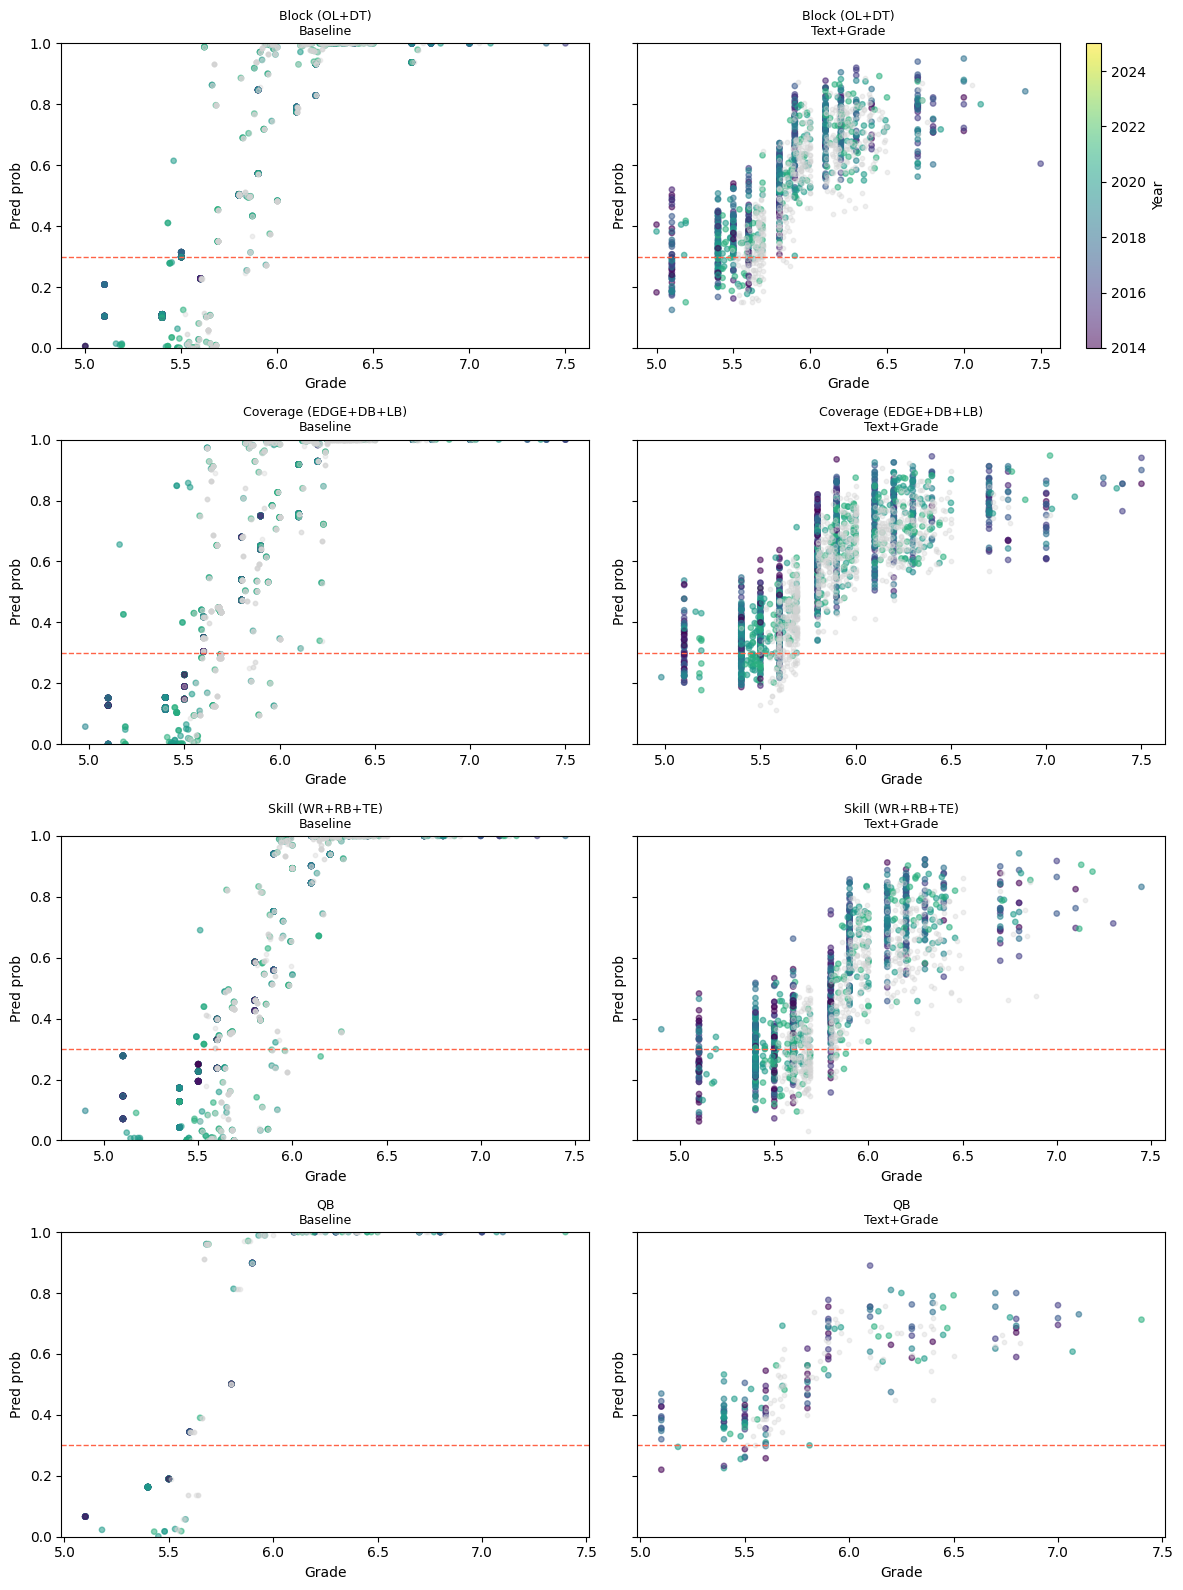

In [8]:
# ── 4×2 scatter: grade vs baseline / grade vs text ────────────────────────────
groups = [
    ('Block (OL+DT)',       scatter_block,    BLOCK),
    ('Coverage (EDGE+DB+LB)', scatter_coverage, COVERAGE),
    ('Skill (WR+RB+TE)',    scatter_skill,    SKILL),
    ('QB',                  scatter_qb,       QB_GRP),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharey='row')
CUTOFF = 0.30

for row_idx, (label, sc, _) in enumerate(groups):
    labeled   = sc[sc['is_drafted'].notna()].copy()
    unlabeled = sc[sc['is_drafted'].isna()].copy()
    colors_l  = labeled['year'].astype(int)
    cmap      = plt.cm.viridis

    for col_idx, score_col in enumerate(['baseline_score', 'text_score']):
        ax = axes[row_idx, col_idx]
        sc_lab = ax.scatter(labeled['grade'], labeled[score_col],
                            c=colors_l, cmap=cmap, alpha=0.55, s=15,
                            vmin=2014, vmax=2025, label='labeled')
        ax.scatter(unlabeled['grade'], unlabeled[score_col],
                   c='lightgray', alpha=0.35, s=10, label='2022-25')
        ax.axhline(CUTOFF, color='tomato', lw=1, ls='--')
        ax.set_title(f'{label}\n{["Baseline", "Text+Grade"][col_idx]}', fontsize=9)
        ax.set_xlabel('Grade'); ax.set_ylabel('Pred prob')
        ax.set_ylim(0, 1)
        if row_idx == 0 and col_idx == 1:
            cbar = fig.colorbar(sc_lab, ax=ax)
            cbar.set_label('Year')

plt.tight_layout()
plt.show()

In [9]:
# ── Section contribution analysis ────────────────────────────────────────────
# Which section (ovr/str/wkn) drives the most RF importance per group?

def section_importance(pipe, label):
    text_pipeline  = pipe.named_steps['features'].transformer_list[0][1]
    tfidf          = text_pipeline.named_steps['tfidf']
    rf             = pipe.named_steps['rf']
    vocab          = {v: k for k, v in tfidf.vocabulary_.items()}
    n_text         = len(vocab)
    importances    = rf.feature_importances_[:n_text]

    sec_imp = {'ovr': 0.0, 'str': 0.0, 'wkn': 0.0, 'other': 0.0}
    for idx, imp in enumerate(importances):
        term = vocab[idx]
        prefix = term.split('_')[0] if '_' in term else 'other'
        if prefix in sec_imp:
            sec_imp[prefix] += imp
        else:
            sec_imp['other'] += imp

    total = sum(sec_imp.values()) or 1
    print(f"  {label}")
    for sec, imp in sorted(sec_imp.items(), key=lambda x: x[1], reverse=True):
        print(f"    {sec:<8} {imp/total:>6.1%}  (abs: {imp:.4f})")

print("=== RF Feature Importance by Section ===")
for pipe, label in [
    (block_pipe,    'Block (OL+DT)'),
    (coverage_pipe, 'Coverage (EDGE+DB+LB)'),
    (skill_pipe,    'Skill (WR+RB+TE)'),
    (qb_pipe,       'QB'),
]:
    section_importance(pipe, label)
    print()

=== RF Feature Importance by Section ===
  Block (OL+DT)
    str       41.5%  (abs: 0.3491)
    wkn       34.3%  (abs: 0.2886)
    ovr       24.2%  (abs: 0.2035)
    other      0.0%  (abs: 0.0000)

  Coverage (EDGE+DB+LB)
    str       40.6%  (abs: 0.3331)
    wkn       33.8%  (abs: 0.2780)
    ovr       25.6%  (abs: 0.2102)
    other      0.0%  (abs: 0.0000)

  Skill (WR+RB+TE)
    str       46.7%  (abs: 0.3885)
    wkn       31.2%  (abs: 0.2594)
    ovr       22.2%  (abs: 0.1846)
    other      0.0%  (abs: 0.0000)

  QB
    str       48.7%  (abs: 0.4226)
    wkn       34.2%  (abs: 0.2969)
    ovr       17.2%  (abs: 0.1491)
    other      0.0%  (abs: 0.0000)



In [10]:
def _strip_prefixes(term):
    """Strip ovr_/str_/wkn_ prefix from each token in a unigram or bigram term."""
    parts = term.split(' ')
    cleaned = []
    for tok in parts:
        idx = tok.find('_')
        cleaned.append(tok[idx+1:] if idx != -1 else tok)
    return ' '.join(cleaned)

def _get_prefix(term):
    """Section prefix from the first token of a possibly-bigram term."""
    first = term.split(' ')[0]
    idx = first.find('_')
    return first[:idx] if idx != -1 else None

def top_section_features(pipe, label, n=15, show_raw=False):
    text_pipeline = pipe.named_steps['features'].transformer_list[0][1]
    tfidf         = text_pipeline.named_steps['tfidf']
    rf            = pipe.named_steps['rf']
    vocab         = {v: k for k, v in tfidf.vocabulary_.items()}
    n_text        = len(vocab)
    importances   = rf.feature_importances_[:n_text]

    by_section = {'ovr': [], 'str': [], 'wkn': []}
    for idx, imp in enumerate(importances):
        term   = vocab[idx]
        prefix = _get_prefix(term)
        if prefix in by_section:
            clean = _strip_prefixes(term)
            by_section[prefix].append((term, clean, imp))

    print(f"=== {label} — Top {n} features per section ===")
    for sec in ['str', 'wkn', 'ovr']:
        top = sorted(by_section[sec], key=lambda x: x[2], reverse=True)[:n]
        print(f"  [{sec.upper()}]  {'Term':<30} {'RF Importance':>14}{'  Raw term' if show_raw else ''}")
        for raw_term, clean, imp in top:
            raw_col = f'  ({raw_term})' if show_raw else ''
            print(f"         {clean:<30} {imp:>14.5f}{raw_col}")
        print()

for pipe, label in [
    (block_pipe,    'Block (OL+DT)'),
    (coverage_pipe, 'Coverage (EDGE+DB+LB)'),
    (skill_pipe,    'Skill (WR+RB+TE)'),
    (qb_pipe,       'QB'),
]:
    top_section_features(pipe, label)

=== Block (OL+DT) — Top 15 features per section ===
  [STR]  Term                            RF Importance
         off snap                              0.00387
         three starter                         0.00385
         upper body                            0.00375
         point attack                          0.00334
         big man                               0.00319
         single block                          0.00313
         pas protection                        0.00284
         pas set                               0.00284
         two gap                               0.00263
         arm length                            0.00260
         play strength                         0.00245
         double team                           0.00244
         body control                          0.00240
         pas rusher                            0.00210
         out stance                            0.00202

  [WKN]  Term                            RF Importance
         bel

In [11]:
# ── Aaron Donald deep dive ───────────────────────────────────────────────────
TARGET = 'Aaron Donald'
ad_row = df[df['player_name'].str.lower() == TARGET.lower()]
if len(ad_row) == 0:
    ad_row = df[df['player_name'].str.contains('Donald', case=False)]
print(f"Found: {ad_row[['player_name','year','Pos_Group','grade','is_drafted']].to_string(index=False)}\n")

ad  = ad_row.iloc[[0]]
ad2 = pd.concat([ad, ad], ignore_index=True)

baseline_prob = block_baseline.predict_proba(ad)[0, 1]
text_prob     = block_pipe.predict_proba(ad2)[0, 1]
print(f"Baseline score:   {baseline_prob:.3f}")
print(f"Text+Grade score: {text_prob:.3f}")
print(f"Text lift:        {text_prob - baseline_prob:+.3f}\n")

text_pipeline = block_pipe.named_steps['features'].transformer_list[0][1]
tfidf         = text_pipeline.named_steps['tfidf']
rf            = block_pipe.named_steps['rf']
vocab         = {v: k for k, v in tfidf.vocabulary_.items()}
n_text        = len(vocab)
importances   = rf.feature_importances_[:n_text]

ad_vec   = tfidf.transform(ad['scouting_text_tagged']).toarray()[0]
combined = ad_vec * importances

by_sec = {'ovr': [], 'str': [], 'wkn': []}
for idx in range(n_text):
    if ad_vec[idx] == 0:
        continue
    term   = vocab[idx]
    prefix = _get_prefix(term)
    if prefix in by_sec:
        clean = _strip_prefixes(term)
        by_sec[prefix].append((clean, term, ad_vec[idx], importances[idx], combined[idx]))

print("=== Donald's top 15 features by section (TF-IDF × RF importance) ===")
print("  clean term = display name | raw = internal prefixed token")
for sec in ['str', 'wkn', 'ovr']:
    top = sorted(by_sec[sec], key=lambda x: x[4], reverse=True)[:15]
    if not top:
        continue
    sec_total = sum(x[4] for x in by_sec[sec])
    print(f"\n  [{sec.upper()}]  section combined importance: {sec_total:.4f}")
    print(f"  {'Term':<25} {'Raw token':<35} {'TF-IDF':>8}  {'RF Imp':>8}  {'Combined':>10}")
    for clean, raw, tf, rf_imp, comb in top:
        print(f"  {clean:<25} {raw:<35} {tf:>8.4f}  {rf_imp:>8.5f}  {comb:>10.6f}")

print("\n=== Which section drove Donald's text score? ===")
for sec in ['str', 'wkn', 'ovr']:
    total  = sum(x[4] for x in by_sec[sec])
    n_terms = len(by_sec[sec])
    print(f"  {sec.upper()}: combined importance {total:.4f}  ({n_terms} active terms)")

Found:  player_name  year Pos_Group  grade is_drafted
Aaron Donald  2014        DT    5.9       True

Baseline score:   0.847
Text+Grade score: 0.935
Text lift:        +0.088

=== Donald's top 15 features by section (TF-IDF × RF importance) ===
  clean term = display name | raw = internal prefixed token

  [STR]  section combined importance: 0.0016
  Term                      Raw token                             TF-IDF    RF Imp    Combined
  off snap                  str_off str_snap                      0.2167   0.00387    0.000839
  football character        str_football str_character            0.3051   0.00064    0.000194
  good foot                 str_good str_foot                     0.2885   0.00067    0.000193
  last three                str_last str_three                    0.3338   0.00042    0.000141
  short area                str_short str_area                    0.2667   0.00042    0.000112
  natural leverage          str_natural str_leverage              0.3403   0.00

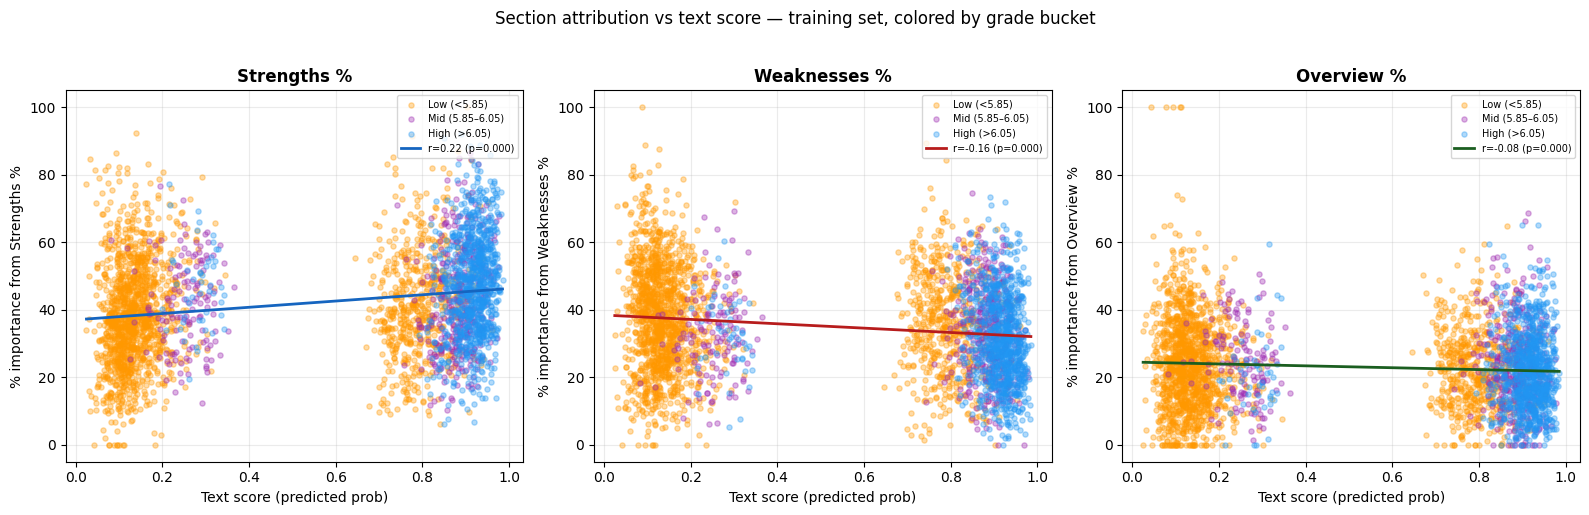


Mean section attribution by grade bucket:
                 str_pct  wkn_pct  ovr_pct
grade_bucket                              
Low (<5.85)         39.3     37.2     23.5
Mid (5.85–6.05)     43.0     33.4     23.7
High (>6.05)        47.2     31.1     21.7

Mean section attribution by Pos_Group:
           str_pct  wkn_pct  ovr_pct
Pos_Group                           
DB            41.6     34.6     23.8
DT            41.4     36.3     22.3
EDGE          41.5     35.9     22.6
LB            40.3     34.4     25.4
OL            39.0     37.5     23.5
QB            47.2     35.2     17.6
RB            46.8     30.3     22.9
TE            40.9     31.3     27.9
WR            44.2     35.2     20.7


In [12]:
# ── Section attribution scatter ─────────────────────────────────────────────
# For each player: what % of their text score comes from STR / WKN / OVR?
from scipy import stats as sp_stats
from scipy.sparse import issparse

def compute_section_attribution(pipe, df_grp):
    text_pipeline = pipe.named_steps['features'].transformer_list[0][1]
    tfidf         = text_pipeline.named_steps['tfidf']
    rf            = pipe.named_steps['rf']
    vocab         = {v: k for k, v in tfidf.vocabulary_.items()}
    n_text        = len(vocab)
    importances   = rf.feature_importances_[:n_text]

    X_text = tfidf.transform(df_grp['scouting_text_tagged'].fillna(''))
    if issparse(X_text):
        X_text = X_text.toarray()
    weighted = X_text * importances[np.newaxis, :]

    sec_masks = {'ovr': np.zeros(n_text, bool),
                 'str': np.zeros(n_text, bool),
                 'wkn': np.zeros(n_text, bool)}
    for idx in range(n_text):
        p = _get_prefix(vocab[idx])
        if p in sec_masks:
            sec_masks[p][idx] = True

    total = weighted.sum(axis=1)
    total = np.where(total == 0, 1, total)

    out = df_grp[['player_name', 'Pos_Group', 'grade', 'is_drafted']].copy().reset_index(drop=True)
    for sec, mask in sec_masks.items():
        out[f'{sec}_pct'] = weighted[:, mask].sum(axis=1) / total * 100
    out['text_score'] = pipe.predict_proba(df_grp)[:, 1]
    return out

attr_parts = []
for pipe, df_grp in [
    (block_pipe,    block_train),
    (coverage_pipe, coverage_train),
    (skill_pipe,    skill_train),
    (qb_pipe,       qb_train),
]:
    attr_parts.append(compute_section_attribution(pipe, df_grp))
attr_df = pd.concat(attr_parts, ignore_index=True)

attr_df['grade_bucket'] = pd.cut(
    attr_df['grade'],
    bins=[0, 5.85, 6.05, 10],
    labels=['Low (<5.85)', 'Mid (5.85–6.05)', 'High (>6.05)']
)

bucket_colors = {'Low (<5.85)': '#FF9800', 'Mid (5.85–6.05)': '#9C27B0', 'High (>6.05)': '#2196F3'}
sections = [('str', 'Strengths %', '#1565C0'),
            ('wkn', 'Weaknesses %', '#B71C1C'),
            ('ovr', 'Overview %',   '#1B5E20')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (sec, sec_label, line_color) in zip(axes, sections):
    for bucket, color in bucket_colors.items():
        mask = attr_df['grade_bucket'] == bucket
        ax.scatter(
            attr_df.loc[mask, 'text_score'],
            attr_df.loc[mask, f'{sec}_pct'],
            c=color, alpha=0.35, s=14, label=bucket, zorder=2
        )
    # regression line
    x = attr_df['text_score'].values
    y = attr_df[f'{sec}_pct'].values
    slope, intercept, r, pval, _ = sp_stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, slope * xs + intercept, color=line_color, lw=2,
            label=f'r={r:.2f} (p={pval:.3f})')
    ax.set_xlabel('Text score (predicted prob)', fontsize=10)
    ax.set_ylabel(f'% importance from {sec_label}', fontsize=10)
    ax.set_title(sec_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.25)

plt.suptitle('Section attribution vs text score — training set, colored by grade bucket',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Also: summary table
print("\nMean section attribution by grade bucket:")
print(attr_df.groupby('grade_bucket', observed=True)[['str_pct','wkn_pct','ovr_pct']].mean().round(1).to_string())
print("\nMean section attribution by Pos_Group:")
print(attr_df.groupby('Pos_Group')[['str_pct','wkn_pct','ovr_pct']].mean().round(1).to_string())

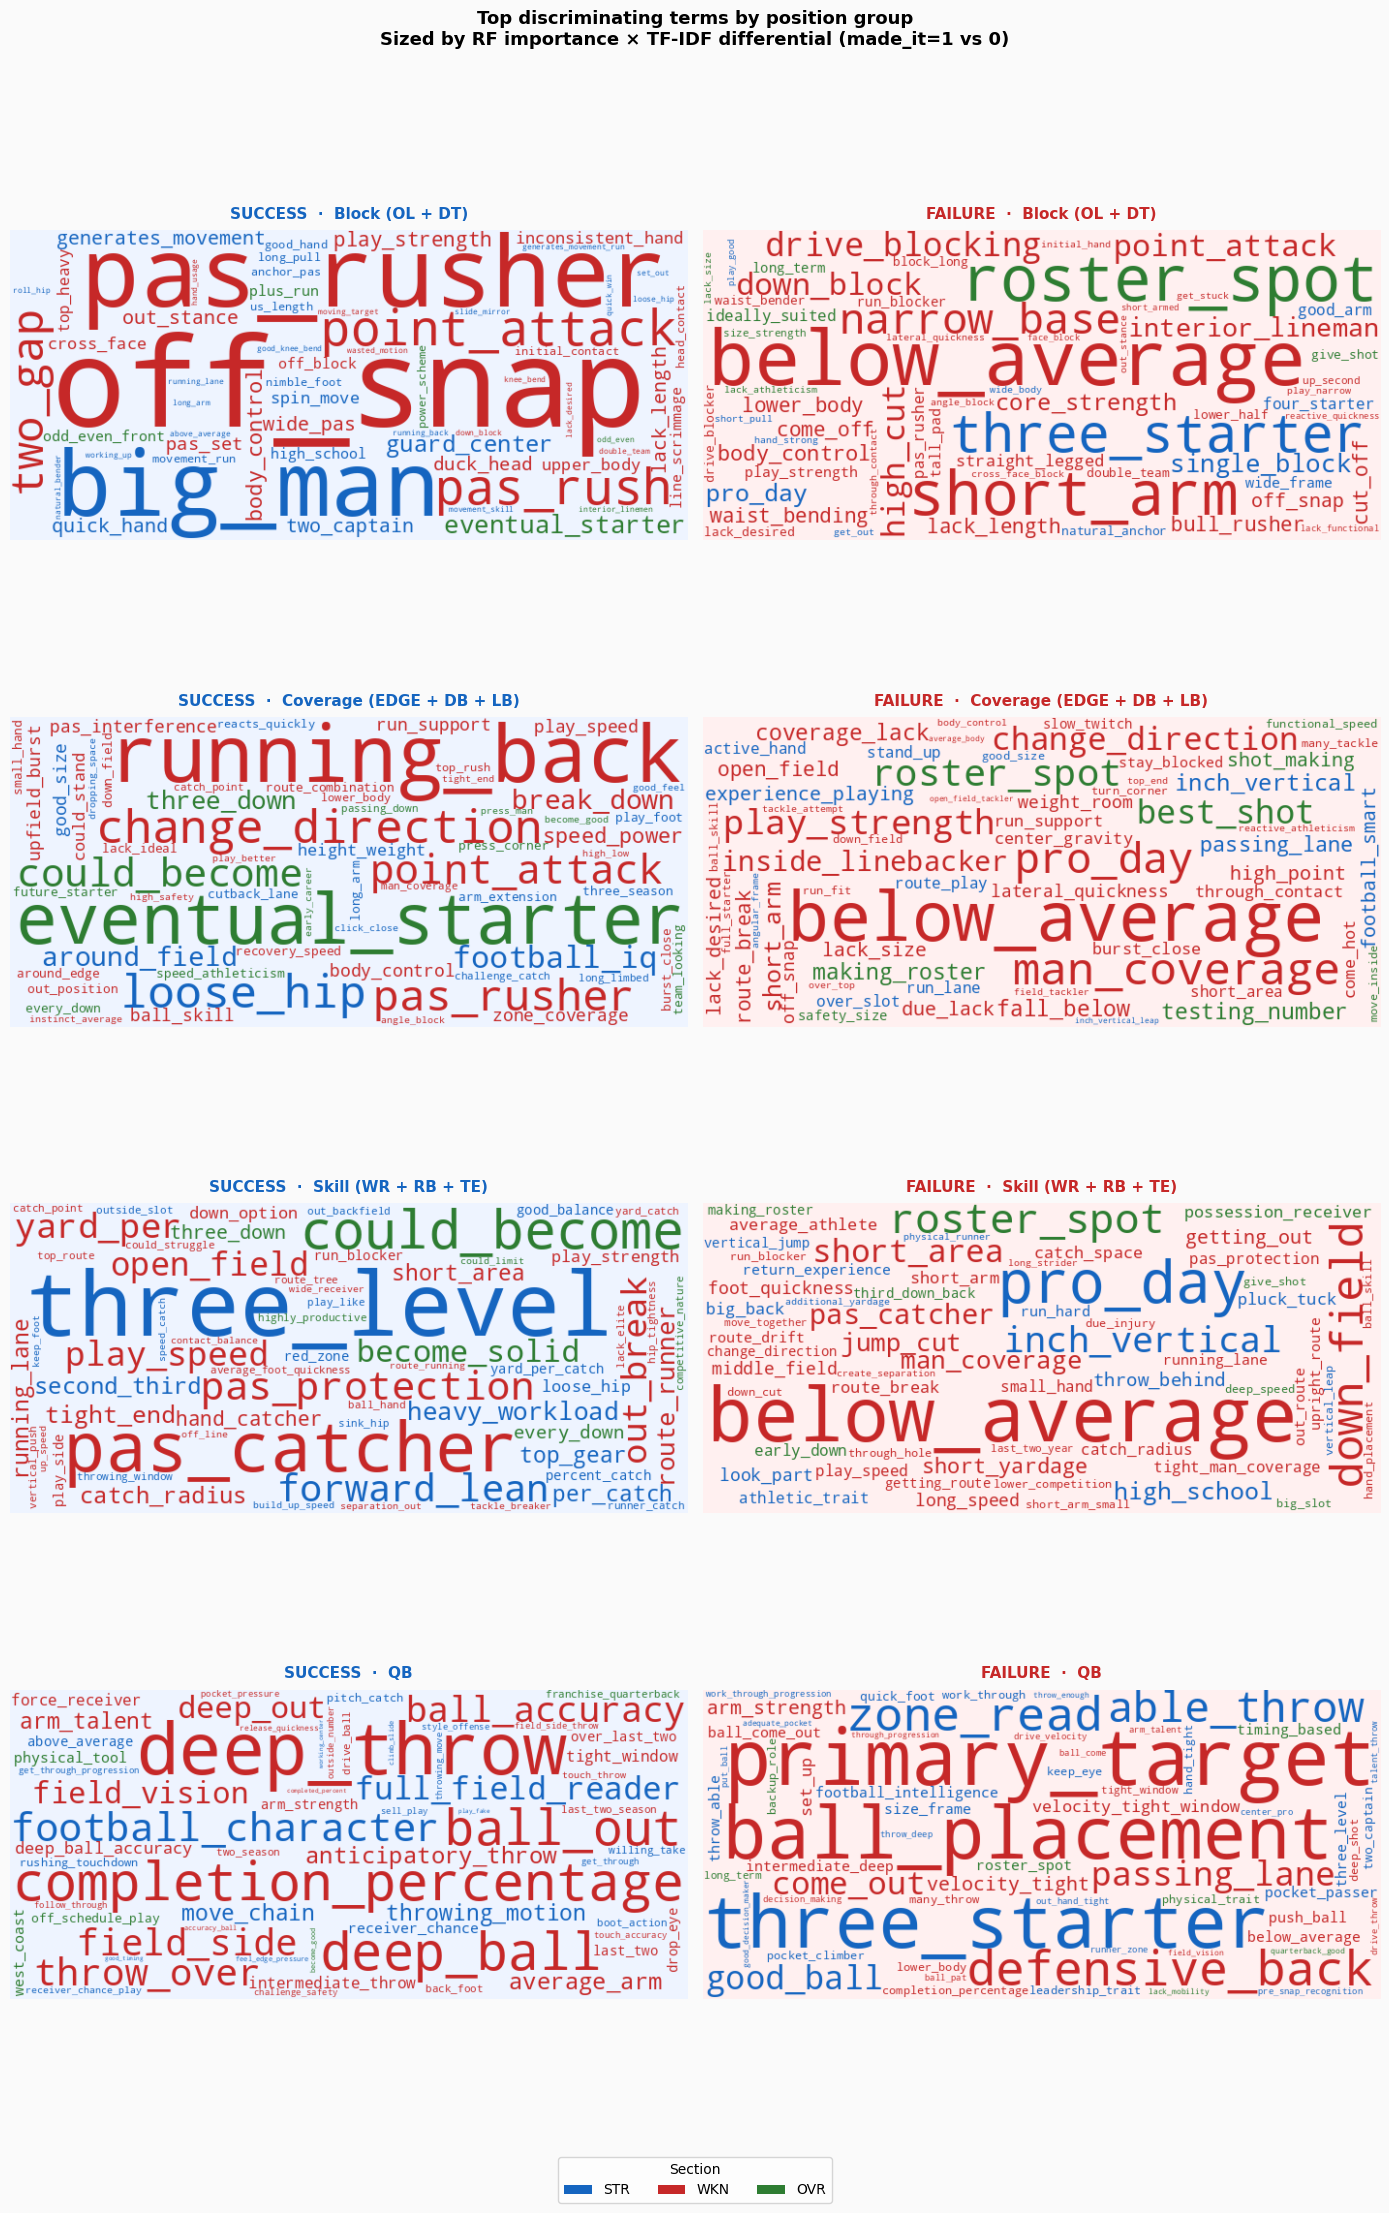

In [13]:
# ── Word clouds: success vs failure terms per position group ─────────────────
# Terms sized by RF_importance × (mean_TFIDF_made_it1 - mean_TFIDF_made_it0)
# Color by section: STR=blue, WKN=red, OVR=green
from wordcloud import WordCloud
from scipy.sparse import issparse

SEC_COLORS = {'str': '#1565C0', 'wkn': '#C62828', 'ovr': '#2E7D32'}

def compute_term_weights(pipe, df_grp, y):
    text_pipeline = pipe.named_steps['features'].transformer_list[0][1]
    tfidf         = text_pipeline.named_steps['tfidf']
    rf            = pipe.named_steps['rf']
    vocab         = {v: k for k, v in tfidf.vocabulary_.items()}
    n_text        = len(vocab)
    importances   = rf.feature_importances_[:n_text]

    X_text = tfidf.transform(df_grp['scouting_text_tagged'].fillna(''))
    if issparse(X_text):
        X_text = X_text.toarray()

    pos_mask = y.values == 1
    neg_mask = ~pos_mask
    mean_pos = X_text[pos_mask].mean(axis=0) if pos_mask.sum() > 0 else np.zeros(n_text)
    mean_neg = X_text[neg_mask].mean(axis=0) if neg_mask.sum() > 0 else np.zeros(n_text)
    diff = (mean_pos - mean_neg) * importances

    success, failure, prefixes = {}, {}, {}
    for idx in range(n_text):
        term    = vocab[idx]
        prefix  = _get_prefix(term)
        display = _strip_prefixes(term).replace(' ', '_')   # bigrams: space→underscore
        prefixes[display] = prefix
        if diff[idx] > 0:
            success[display] = float(diff[idx])
        elif diff[idx] < 0:
            failure[display] = float(-diff[idx])

    return success, failure, prefixes

def make_color_func(prefixes):
    def color_func(word, **kwargs):
        return SEC_COLORS.get(prefixes.get(word, 'ovr'), '#555555')
    return color_func

groups_wc = [
    (block_pipe,    block_train,    y_block,    'Block (OL + DT)'),
    (coverage_pipe, coverage_train, y_coverage, 'Coverage (EDGE + DB + LB)'),
    (skill_pipe,    skill_train,    y_skill,    'Skill (WR + RB + TE)'),
    (qb_pipe,       qb_train,       y_qb,       'QB'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.patch.set_facecolor('#FAFAFA')

for row, (pipe, df_grp, y, label) in enumerate(groups_wc):
    success, failure, prefixes = compute_term_weights(pipe, df_grp, y)
    cf = make_color_func(prefixes)

    for col, (weights, title, bg, border) in enumerate([
        (success, f'SUCCESS  ·  {label}', '#EEF4FF', '#1565C0'),
        (failure, f'FAILURE  ·  {label}', '#FFF0F0', '#C62828'),
    ]):
        ax = axes[row][col]
        ax.set_facecolor(bg)
        if weights:
            wc = WordCloud(
                width=700, height=320,
                background_color=bg,
                max_words=60,
                prefer_horizontal=0.80,
                color_func=cf,
                collocations=False,
            ).generate_from_frequencies(weights)
            ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8,
                     color=border)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(border)
            spine.set_linewidth(1.5)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=s.upper())
              for s, c in SEC_COLORS.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=3,
           fontsize=10, title='Section', title_fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, 0.005))

plt.suptitle('Top discriminating terms by position group\n'
             'Sized by RF importance × TF-IDF differential (made_it=1 vs 0)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

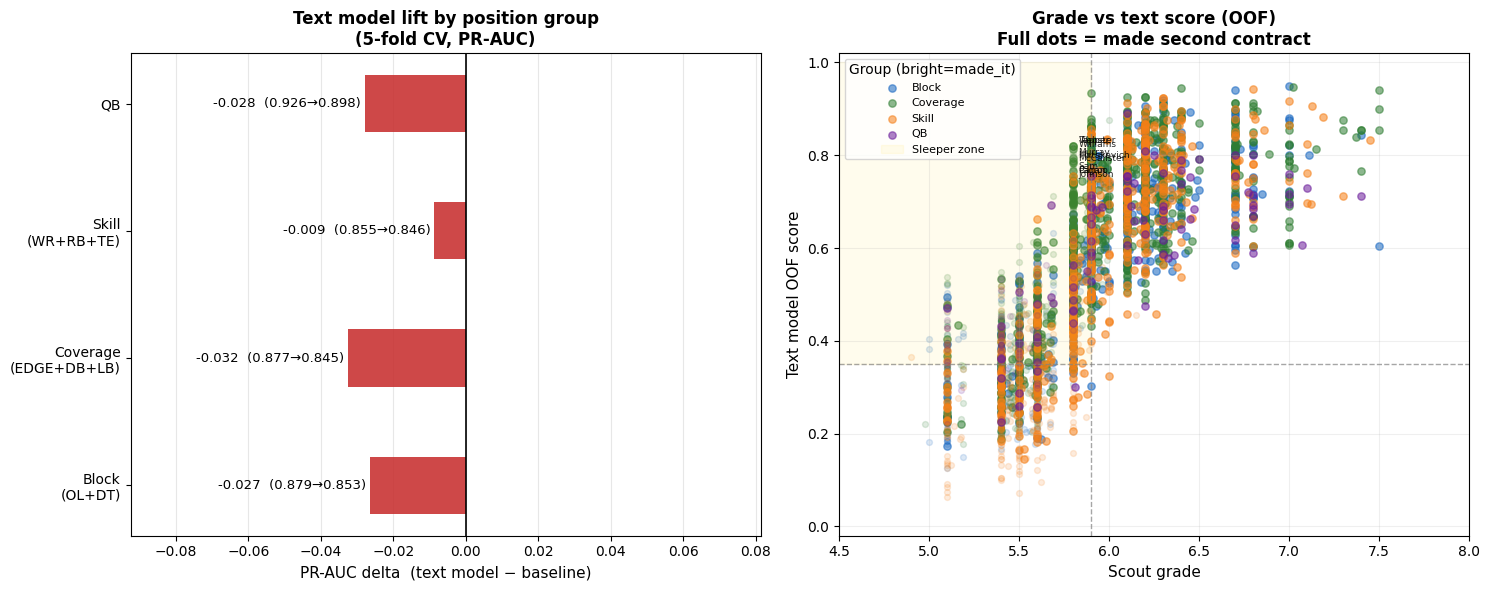

In [14]:
# ── Text lift bar chart + sleeper scatter ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── LEFT: horizontal delta bars ───────────────────────────────────────────────
grp_labels  = ['Block\n(OL+DT)', 'Coverage\n(EDGE+DB+LB)', 'Skill\n(WR+RB+TE)', 'QB']
base_scores = [block_base_cv.mean(), cov_base_cv.mean(), skill_base_cv.mean(), qb_base_cv.mean()]
text_scores = [block_text_cv.mean(), cov_text_cv.mean(), skill_text_cv.mean(), qb_text_cv.mean()]
deltas      = [t - b for t, b in zip(text_scores, base_scores)]
bar_colors  = ['#1565C0' if d > 0 else '#C62828' for d in deltas]

ax = axes[0]
bars = ax.barh(grp_labels, deltas, color=bar_colors, alpha=0.85, height=0.45, zorder=2)
ax.axvline(0, color='black', lw=1.2, zorder=3)
ax.grid(axis='x', alpha=0.3, zorder=1)

for bar, delta, b, t in zip(bars, deltas, base_scores, text_scores):
    pad = 0.001
    ha  = 'left' if delta >= 0 else 'right'
    x   = delta + pad if delta >= 0 else delta - pad
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{delta:+.3f}  ({b:.3f}→{t:.3f})',
            va='center', ha=ha, fontsize=9.5)

ax.set_xlabel('PR-AUC delta  (text model − baseline)', fontsize=11)
ax.set_title('Text model lift by position group\n(5-fold CV, PR-AUC)', fontsize=12, fontweight='bold')
ax.set_xlim(min(deltas) - 0.06, max(deltas) + 0.09)

# ── RIGHT: grade vs text_score scatter, highlight sleepers ───────────────────
# Combine all training groups with their OOF scores
all_parts = []
for df_grp, oof, grp_name in [
    (block_train,    oof_block,    'Block'),
    (coverage_train, oof_coverage, 'Coverage'),
    (skill_train,    oof_skill,    'Skill'),
    (qb_train,       oof_qb,       'QB'),
]:
    tmp = df_grp[['player_name', 'Pos_Group', 'grade', 'is_drafted']].copy().reset_index(drop=True)
    tmp['text_score'] = oof
    tmp['group']      = grp_name
    all_parts.append(tmp)
scatter_all = pd.concat(all_parts, ignore_index=True)

SLEEPER_GRADE = 5.9
SLEEPER_THRESH = 0.35

GRP_COLORS = {'Block': '#1565C0', 'Coverage': '#2E7D32', 'Skill': '#F57F17', 'QB': '#6A1B9A'}

ax2 = axes[1]
for grp, color in GRP_COLORS.items():
    m = scatter_all['group'] == grp
    made = m & (scatter_all['is_drafted'] == 1)
    miss = m & (scatter_all['is_drafted'] == 0)
    ax2.scatter(scatter_all.loc[miss, 'grade'], scatter_all.loc[miss, 'text_score'],
                c=color, alpha=0.15, s=18, marker='o')
    ax2.scatter(scatter_all.loc[made, 'grade'], scatter_all.loc[made, 'text_score'],
                c=color, alpha=0.55, s=28, marker='o', label=grp)

# Sleeper quadrant box
ax2.axvline(SLEEPER_GRADE,  color='gray', lw=1, ls='--', alpha=0.7)
ax2.axhline(SLEEPER_THRESH, color='gray', lw=1, ls='--', alpha=0.7)
ax2.fill_betweenx([SLEEPER_THRESH, 1.0], 0, SLEEPER_GRADE,
                  alpha=0.07, color='gold', label='Sleeper zone')

# Label notable sleepers (low grade, high text score, made_it=1)
sleepers_plot = scatter_all[
    (scatter_all['grade'] < SLEEPER_GRADE) &
    (scatter_all['text_score'] >= SLEEPER_THRESH) &
    (scatter_all['is_drafted'] == 1)
].nlargest(10, 'text_score')

for _, row in sleepers_plot.iterrows():
    ax2.annotate(
        row['player_name'].split()[-1],   # last name only
        xy=(row['grade'], row['text_score']),
        xytext=(4, 2), textcoords='offset points',
        fontsize=6.5, alpha=0.85,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    )

ax2.set_xlabel('Scout grade', fontsize=11)
ax2.set_ylabel('Text model OOF score', fontsize=11)
ax2.set_title('Grade vs text score (OOF)\nFull dots = made second contract', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left', title='Group (bright=made_it)')
ax2.set_xlim(4.5, 8.0)
ax2.set_ylim(-0.02, 1.02)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

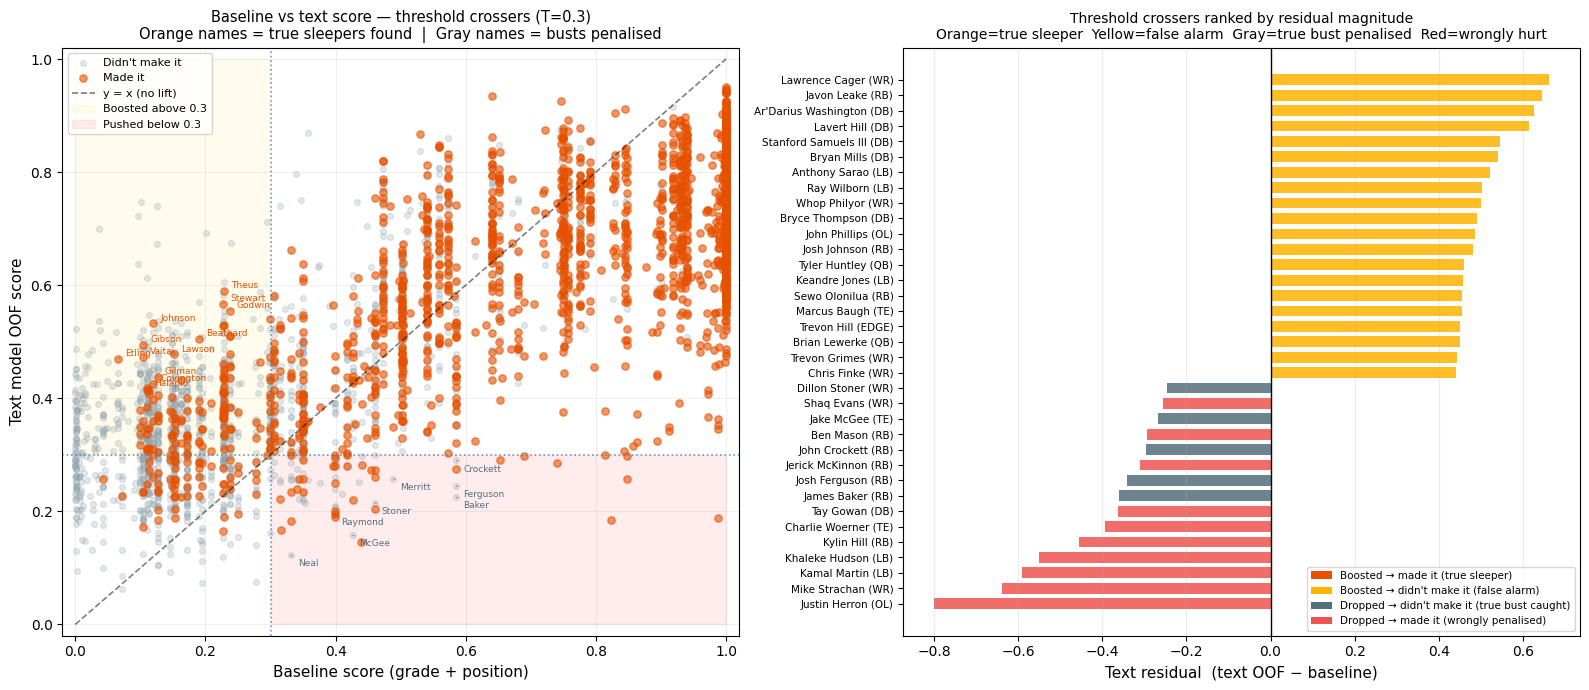

Threshold = 0.3
Boosted above threshold:  749 players
  → made it (true sleepers):  135
  → didn't (false alarms):    614
Pushed below threshold:   72 players
  → didn't (correct):         40
  → made it (wrong):          32


In [15]:
# ── Residual plot: who did the text model push across the threshold? ──────────
# x = baseline score, y = text OOF score
# y=x diagonal = no lift from text
# Threshold lines divide the space into quadrants:
#   Top-left   (base<T, text>=T): text boosted above threshold
#   Bottom-right (base>=T, text<T): text pushed below threshold
# Color = actual outcome. Annotate players who crossed AND got it right.

THRESH = 0.3

# Rebuild combined scatter (OOF for text, in-sample for baseline)
_parts = []
for df_grp, oof, base_pipe, grp in [
    (block_train,    oof_block,    block_baseline,    'Block'),
    (coverage_train, oof_coverage, coverage_baseline, 'Coverage'),
    (skill_train,    oof_skill,    skill_baseline,    'Skill'),
    (qb_train,       oof_qb,       qb_baseline,       'QB'),
]:
    tmp = df_grp[['player_name', 'Pos_Group', 'grade', 'is_drafted']].copy().reset_index(drop=True)
    tmp['text_oof']  = oof
    tmp['base_score'] = base_pipe.predict_proba(df_grp)[:, 1]
    tmp['residual']   = tmp['text_oof'] - tmp['base_score']
    tmp['group']      = grp
    _parts.append(tmp)
resid_df = pd.concat(_parts, ignore_index=True)

# Classify each player into crossing quadrant
resid_df['crossed_up']   = (resid_df['base_score'] < THRESH) & (resid_df['text_oof'] >= THRESH)
resid_df['crossed_down'] = (resid_df['base_score'] >= THRESH) & (resid_df['text_oof'] < THRESH)
resid_df['crossed']      = resid_df['crossed_up'] | resid_df['crossed_down']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

OUTCOME_COLORS = {1: '#E65100', 0: '#546E7A'}   # orange = made it, slate = didn't

# ── LEFT: full scatter ────────────────────────────────────────────────────────
ax = axes[0]
for made, color, label, alpha, size in [
    (0, '#90A4AE', "Didn't make it", 0.25, 18),
    (1, '#E65100', 'Made it',        0.60, 28),
]:
    m = resid_df['is_drafted'] == made
    ax.scatter(resid_df.loc[m, 'base_score'], resid_df.loc[m, 'text_oof'],
               c=color, alpha=alpha, s=size, label=label, zorder=2)

# y=x line
lims = [0, 1]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='y = x (no lift)', zorder=3)

# Threshold lines + quadrant shading
ax.axvline(THRESH, color='steelblue', lw=1.2, ls=':', alpha=0.8)
ax.axhline(THRESH, color='steelblue', lw=1.2, ls=':', alpha=0.8)

ax.fill_between([0, THRESH], THRESH, 1.0, alpha=0.07, color='gold',
                label=f'Boosted above {THRESH}')
ax.fill_between([THRESH, 1.0], 0, THRESH, alpha=0.07, color='red',
                label=f'Pushed below {THRESH}')

# Annotate top boosted true positives (crossed_up, made_it=1)
boosted_tp = resid_df[resid_df['crossed_up'] & (resid_df['is_drafted'] == 1)].nlargest(12, 'residual')
for _, row in boosted_tp.iterrows():
    ax.annotate(row['player_name'].split()[-1],
                xy=(row['base_score'], row['text_oof']),
                xytext=(5, 2), textcoords='offset points',
                fontsize=6.5, color='#E65100',
                arrowprops=dict(arrowstyle='-', color='#E65100', lw=0.5))

# Annotate top penalised true negatives (crossed_down, made_it=0)
penalised_tn = resid_df[resid_df['crossed_down'] & (resid_df['is_drafted'] == 0)].nsmallest(8, 'residual')
for _, row in penalised_tn.iterrows():
    ax.annotate(row['player_name'].split()[-1],
                xy=(row['base_score'], row['text_oof']),
                xytext=(5, -8), textcoords='offset points',
                fontsize=6.5, color='#546E7A',
                arrowprops=dict(arrowstyle='-', color='#546E7A', lw=0.5))

ax.set_xlabel('Baseline score (grade + position)', fontsize=11)
ax.set_ylabel('Text model OOF score', fontsize=11)
ax.set_title(f'Baseline vs text score — threshold crossers (T={THRESH})\n'
             f'Orange names = true sleepers found  |  Gray names = busts penalised', fontsize=10.5)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.2)

# ── RIGHT: residual bar chart, top crossers ────────────────────────────────────
ax2 = axes[1]

# Top 20 boosted (crossed_up, any outcome) by residual
up   = resid_df[resid_df['crossed_up']].nlargest(20, 'residual').copy()
# Top 15 dropped (crossed_down, any outcome) by residual magnitude
down = resid_df[resid_df['crossed_down']].nsmallest(15, 'residual').copy()

combined = pd.concat([up, down]).sort_values('residual', ascending=True)
bar_colors = combined.apply(
    lambda r: '#E65100' if (r['crossed_up']   and r['is_drafted'] == 1) else
              '#FFB300' if (r['crossed_up']   and r['is_drafted'] == 0) else
              '#546E7A' if (r['crossed_down'] and r['is_drafted'] == 0) else
              '#EF5350',   # crossed_down but made_it=1 (text wrongly hurt them)
    axis=1
)
labels = combined['player_name'] + ' (' + combined['Pos_Group'] + ')'

ax2.barh(range(len(combined)), combined['residual'], color=bar_colors.values, alpha=0.85, height=0.7)
ax2.set_yticks(range(len(combined)))
ax2.set_yticklabels(labels, fontsize=7.5)
ax2.axvline(0, color='black', lw=1)
ax2.set_xlabel('Text residual  (text OOF − baseline)', fontsize=11)
ax2.set_title('Threshold crossers ranked by residual magnitude\n'
              'Orange=true sleeper  Yellow=false alarm  Gray=true bust penalised  Red=wrongly hurt', fontsize=10)
ax2.grid(axis='x', alpha=0.25)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#E65100', label='Boosted → made it (true sleeper)'),
    Patch(facecolor='#FFB300', label="Boosted → didn't make it (false alarm)"),
    Patch(facecolor='#546E7A', label="Dropped → didn't make it (true bust caught)"),
    Patch(facecolor='#EF5350', label='Dropped → made it (wrongly penalised)'),
]
ax2.legend(handles=legend_els, fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.show()

# Summary counts
print(f"Threshold = {THRESH}")
print(f"Boosted above threshold:  {resid_df['crossed_up'].sum()} players")
print(f"  → made it (true sleepers):  {(resid_df['crossed_up'] & (resid_df['is_drafted']==1)).sum()}")
print(f"  → didn't (false alarms):    {(resid_df['crossed_up'] & (resid_df['is_drafted']==0)).sum()}")
print(f"Pushed below threshold:   {resid_df['crossed_down'].sum()} players")
print(f"  → didn't (correct):         {(resid_df['crossed_down'] & (resid_df['is_drafted']==0)).sum()}")
print(f"  → made it (wrong):          {(resid_df['crossed_down'] & (resid_df['is_drafted']==1)).sum()}")

Sleeper Zone (grade < 6.5) — Top-25 Evaluation (OOF)
Flagging: rank by model score within sleeper zone → top 25 = predicted sleepers
Group        N slp   Base%         ── Baseline ──               ── Text+Grade ──      
                             Prec@25    Rec@25     PR-AUC   Prec@25    Rec@25     PR-AUC
----------------------------------------------------------------------------------
Block          803   52.6%    100.0%      5.9%     0.8511     84.0%      5.0%     0.8142
Coverage      1251   55.9%     96.0%      3.4%     0.8430     96.0%      3.4%     0.8052
Skill          970   47.5%    100.0%      5.4%     0.8244     96.0%      5.2%     0.8169
QB             138   50.7%    100.0%     35.7%     0.8829     96.0%     34.3%     0.8505


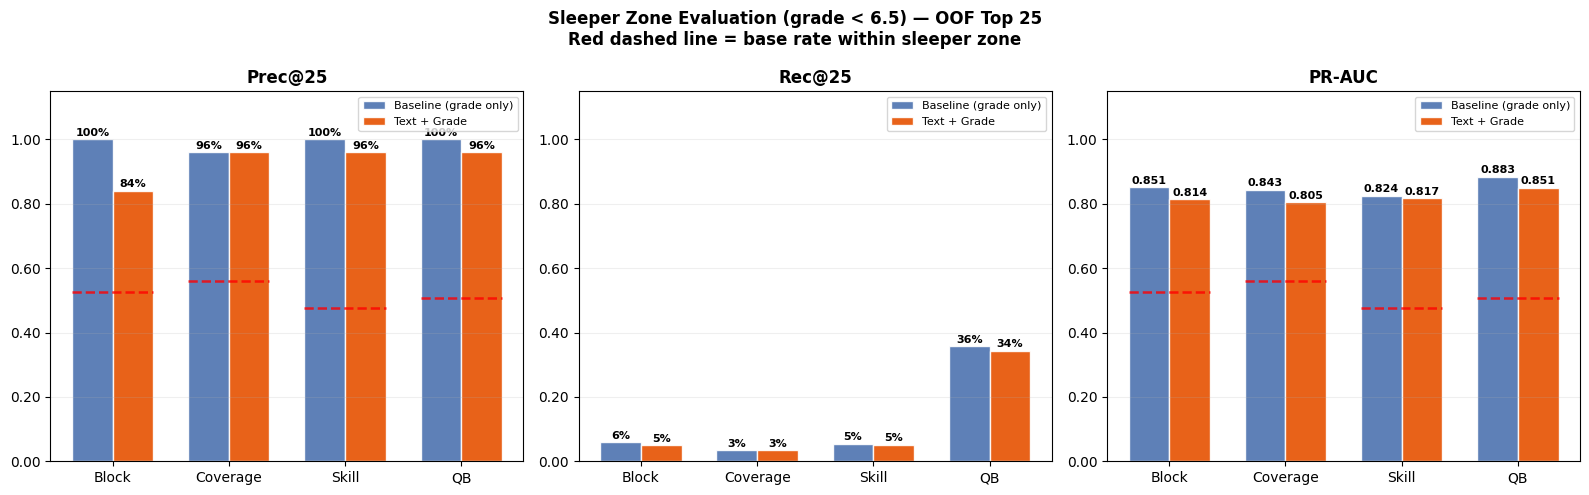

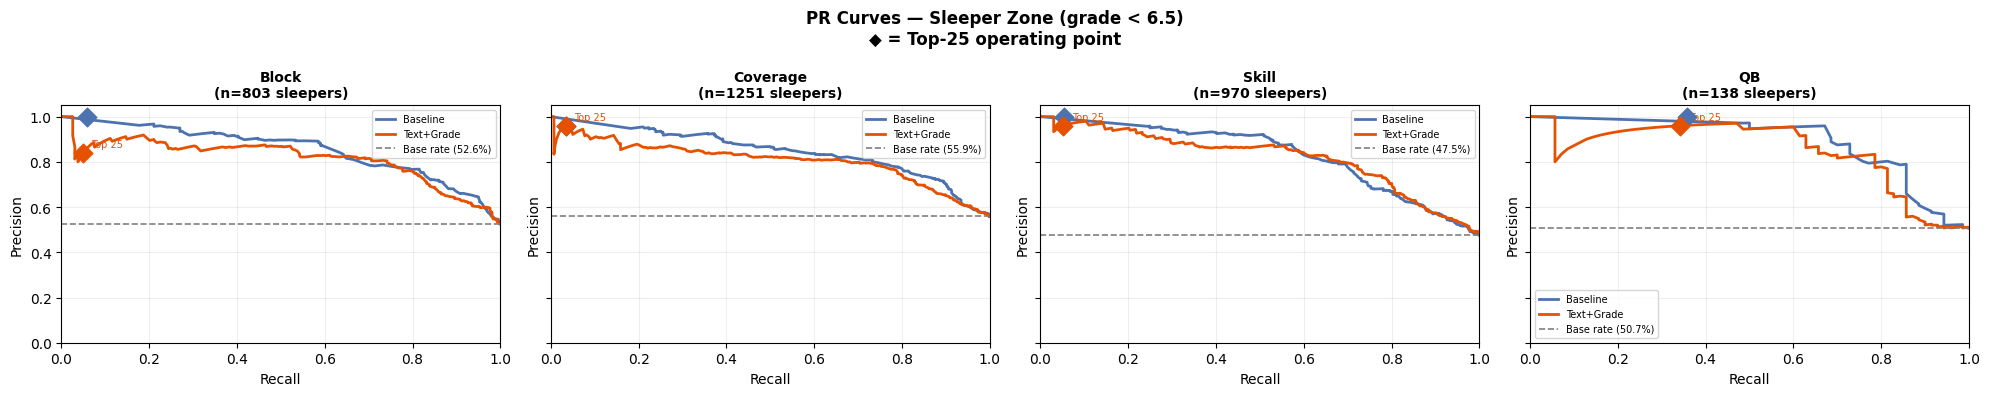


Top-25 Predicted Sleepers per Group  (grade < 6.5, ranked by text+grade OOF score)
These are the players the model backs despite a low scout grade.

Block  —  15/25 made it  (60% vs sleeper base rate 52.6%)
       player_name Pos_Group  grade  text_score  base_score made_it_contract  year
     Taylor Decker        OL  6.300       0.920       1.000             True  2016
    Joshua Garnett        OL  6.300       0.912       1.000            False  2016
    Foley Fatukasi        DT  6.200       0.905       0.798             True  2018
        Ryan Kelly        OL  6.300       0.895       1.000             True  2016
Christian Darrisaw        OL  6.450       0.892       1.000             True  2021
   Saahdiq Charles        OL  6.200       0.882       0.956            False  2020
        Shaq Mason        OL  6.100       0.877       0.748             True  2015
    Elgton Jenkins        OL  6.300       0.877       1.000             True  2019
    Jordan Elliott        DT  6.360       0.8

In [16]:

# ── Sleeper Zone Evaluation: Top-25 Precision, Recall, PR-AUC ────────────────
# Sleeper = player with grade < SLEEPER_GRADE (overlooked by scouts).
# Flag = model's OOF predicted probability (no outcome data used for flagging).
# Within the sleeper zone, rank players by model score → top 25 = predicted sleepers.
# Then check: how many of those 25 actually made it? Compare baseline vs text+grade.

from sklearn.metrics import average_precision_score, precision_recall_curve

SLEEPER_GRADE = 6.5
K = 25

# Recompute OOF baseline scores (fair OOF comparison — baseline was fit in-sample)
oof_base_block    = cross_val_predict(make_baseline_pipe(), block_train[['grade','Pos_Group']],
                                      y_block,    cv=cv, method='predict_proba')[:, 1]
oof_base_coverage = cross_val_predict(make_baseline_pipe(), coverage_train[['grade','Pos_Group']],
                                      y_coverage, cv=cv, method='predict_proba')[:, 1]
oof_base_skill    = cross_val_predict(make_baseline_pipe(), skill_train[['grade','Pos_Group']],
                                      y_skill,    cv=cv, method='predict_proba')[:, 1]
oof_base_qb       = cross_val_predict(make_baseline_pipe(), qb_train[['grade','Pos_Group']],
                                      y_qb,       cv=cv, method='predict_proba')[:, 1]

ALL_GROUPS = {
    'Block':    (block_train,    y_block,    oof_block,    oof_base_block),
    'Coverage': (coverage_train, y_coverage, oof_coverage, oof_base_coverage),
    'Skill':    (skill_train,    y_skill,    oof_skill,    oof_base_skill),
    'QB':       (qb_train,       y_qb,       oof_qb,       oof_base_qb),
}

def prec_rec_at_k(y_true, scores, k):
    y_arr = np.asarray(y_true)
    top_k = min(k, len(y_arr))
    idx   = np.argsort(scores)[::-1][:top_k]
    prec  = y_arr[idx].mean()
    rec   = y_arr[idx].sum() / max(y_arr.sum(), 1)
    return prec, rec

# ── 1. Summary table ──────────────────────────────────────────────────────────
print(f"Sleeper Zone (grade < {SLEEPER_GRADE}) — Top-{K} Evaluation (OOF)")
print(f"Flagging: rank by model score within sleeper zone → top {K} = predicted sleepers")
print("=" * 82)
print(f"{'Group':<10}  {'N slp':>6}  {'Base%':>6}  "
      f"{'── Baseline ──':^28}  {'── Text+Grade ──':^28}")
print(f"{'':10}  {'':6}  {'':6}  "
      f"{'Prec@25':>8}  {'Rec@25':>8}  {'PR-AUC':>9}  "
      f"{'Prec@25':>8}  {'Rec@25':>8}  {'PR-AUC':>9}")
print("-" * 82)

records = []
for grp, (train_df, y, t_oof, b_oof) in ALL_GROUPS.items():
    # Filter to sleeper zone only
    sl_mask   = train_df['grade'].values < SLEEPER_GRADE
    y_sl      = np.asarray(y)[sl_mask]
    t_oof_sl  = t_oof[sl_mask]
    b_oof_sl  = b_oof[sl_mask]

    n_sl      = sl_mask.sum()
    base_rate = y_sl.mean()

    if n_sl < K:
        print(f"{grp:<10}  {n_sl:>6}  — too few sleepers for @{K} eval —")
        continue

    b_prec, b_rec = prec_rec_at_k(y_sl, b_oof_sl, K)
    t_prec, t_rec = prec_rec_at_k(y_sl, t_oof_sl, K)
    b_prauc       = average_precision_score(y_sl, b_oof_sl)
    t_prauc       = average_precision_score(y_sl, t_oof_sl)

    print(f"{grp:<10}  {n_sl:>6}  {base_rate:>6.1%}  "
          f"{b_prec:>8.1%}  {b_rec:>8.1%}  {b_prauc:>9.4f}  "
          f"{t_prec:>8.1%}  {t_rec:>8.1%}  {t_prauc:>9.4f}")
    records.append(dict(Group=grp, N_sleepers=n_sl, Base_rate=base_rate,
                        Base_Prec=b_prec, Base_Rec=b_rec, Base_PRAUC=b_prauc,
                        Text_Prec=t_prec, Text_Rec=t_rec, Text_PRAUC=t_prauc,
                        Delta_Prec=t_prec - b_prec, Delta_PRAUC=t_prauc - b_prauc))

eval_df = pd.DataFrame(records)

# ── 2. Bar charts ─────────────────────────────────────────────────────────────
COLOR_BASE = '#4C72B0'
COLOR_TEXT = '#E65100'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('Prec@25',  'Base_Prec',  'Text_Prec',  True),
           ('Rec@25',   'Base_Rec',   'Text_Rec',   False),
           ('PR-AUC',   'Base_PRAUC', 'Text_PRAUC', True)]

for ax, (label, base_col, text_col, show_base_rate) in zip(axes, metrics):
    x = np.arange(len(eval_df))
    w = 0.35
    b_bars = ax.bar(x - w/2, eval_df[base_col], width=w, color=COLOR_BASE,
                    label='Baseline (grade only)', alpha=0.9, edgecolor='white')
    t_bars = ax.bar(x + w/2, eval_df[text_col],  width=w, color=COLOR_TEXT,
                    label='Text + Grade',          alpha=0.9, edgecolor='white')

    for bar in list(b_bars) + list(t_bars):
        h = bar.get_height()
        fmt = f'{h:.0%}' if label != 'PR-AUC' else f'{h:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                fmt, ha='center', va='bottom', fontsize=8, fontweight='bold')

    if show_base_rate:
        for i, row in eval_df.iterrows():
            ax.plot([i - w, i + w], [row['Base_rate'], row['Base_rate']],
                    color='red', lw=1.8, ls='--', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(eval_df['Group'], fontsize=10)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}' if label != 'PR-AUC' else f'{v:.2f}'))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle(f'Sleeper Zone Evaluation (grade < {SLEEPER_GRADE}) — OOF Top {K}\n'
             f'Red dashed line = base rate within sleeper zone',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. PR curves within sleeper zone ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(eval_df), figsize=(5 * len(eval_df), 4), sharey=True)
if len(eval_df) == 1:
    axes2 = [axes2]

for ax, (_, row) in zip(axes2, eval_df.iterrows()):
    grp = row['Group']
    train_df, y, t_oof, b_oof = ALL_GROUPS[grp]
    sl_mask  = train_df['grade'].values < SLEEPER_GRADE
    y_sl     = np.asarray(y)[sl_mask]
    t_oof_sl = t_oof[sl_mask]
    b_oof_sl = b_oof[sl_mask]

    for scores, color, label in [(b_oof_sl, COLOR_BASE, 'Baseline'),
                                  (t_oof_sl, COLOR_TEXT,  'Text+Grade')]:
        p_c, r_c, _ = precision_recall_curve(y_sl, scores)
        ax.plot(r_c, p_c, color=color, lw=2, label=label)

    ax.axhline(row['Base_rate'], color='grey', ls='--', lw=1.2,
               label=f'Base rate ({row["Base_rate"]:.1%})')

    # Mark Top-K operating points
    for scores, color, prec_k, rec_k in [
        (b_oof_sl, COLOR_BASE, row['Base_Prec'], row['Base_Rec']),
        (t_oof_sl, COLOR_TEXT, row['Text_Prec'], row['Text_Rec']),
    ]:
        ax.scatter([rec_k], [prec_k], color=color, s=90, zorder=5, marker='D')

    ax.annotate(f'Top {K}', xy=(row['Text_Rec'], row['Text_Prec']),
                xytext=(6, 4), textcoords='offset points', fontsize=7, color=COLOR_TEXT)

    ax.set_title(f'{grp}\n(n={int(row["N_sleepers"])} sleepers)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=7); ax.grid(alpha=0.2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

fig2.suptitle(f'PR Curves — Sleeper Zone (grade < {SLEEPER_GRADE})\n'
              f'◆ = Top-{K} operating point',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Named top-25 predicted sleepers per group (text+grade model) ───────────
print(f"\nTop-{K} Predicted Sleepers per Group  (grade < {SLEEPER_GRADE}, ranked by text+grade OOF score)")
print("These are the players the model backs despite a low scout grade.")
print("=" * 70)

for grp, (train_df, y, t_oof, b_oof) in ALL_GROUPS.items():
    sl_mask = train_df['grade'].values < SLEEPER_GRADE
    sl_df   = train_df[sl_mask][['player_name', 'Pos_Group', 'grade',
                                  'made_it_contract', 'year']].copy().reset_index(drop=True)
    sl_df['text_score'] = t_oof[sl_mask]
    sl_df['base_score'] = b_oof[sl_mask]
    top25 = sl_df.nlargest(K, 'text_score')

    n_made  = top25['made_it_contract'].sum()
    base_rt = np.asarray(y)[sl_mask].mean()
    print(f"\n{grp}  —  {n_made}/{K} made it  "
          f"({n_made/K:.0%} vs sleeper base rate {base_rt:.1%})")
    print(top25[['player_name', 'Pos_Group', 'grade',
                 'text_score', 'base_score', 'made_it_contract', 'year']]
          .to_string(index=False, float_format='{:.3f}'.format))


Sleeper Zone Delta Analysis  (grade < 6.5, K = 25)
Which players does text+grade find that grade alone misses — and are they right?

Block  (sleeper base rate = 52.6%)
  Overlap (both lists):          5 players  →  80.0% made it
  Text finds  (text not grade): 20 players  →  55.0% made it  ← text adds these
  Grade finds (grade not text): 20 players  →  50.0% made it  ← text removes these
  Text lift over demoted:      +5.0%  (positive = text swap was correct)

  Players text rescues (not in grade top-25):
       player_name Pos_Group  grade  text_score  base_score made_it_contract
    Foley Fatukasi        DT  6.200       0.905       0.798             True
Christian Darrisaw        OL  6.450       0.892       1.000             True
   Saahdiq Charles        OL  6.200       0.882       0.956            False
    Elgton Jenkins        OL  6.300       0.877       1.000             True
        Shaq Mason        OL  6.100       0.877       0.748             True
    Jordan Elliott        

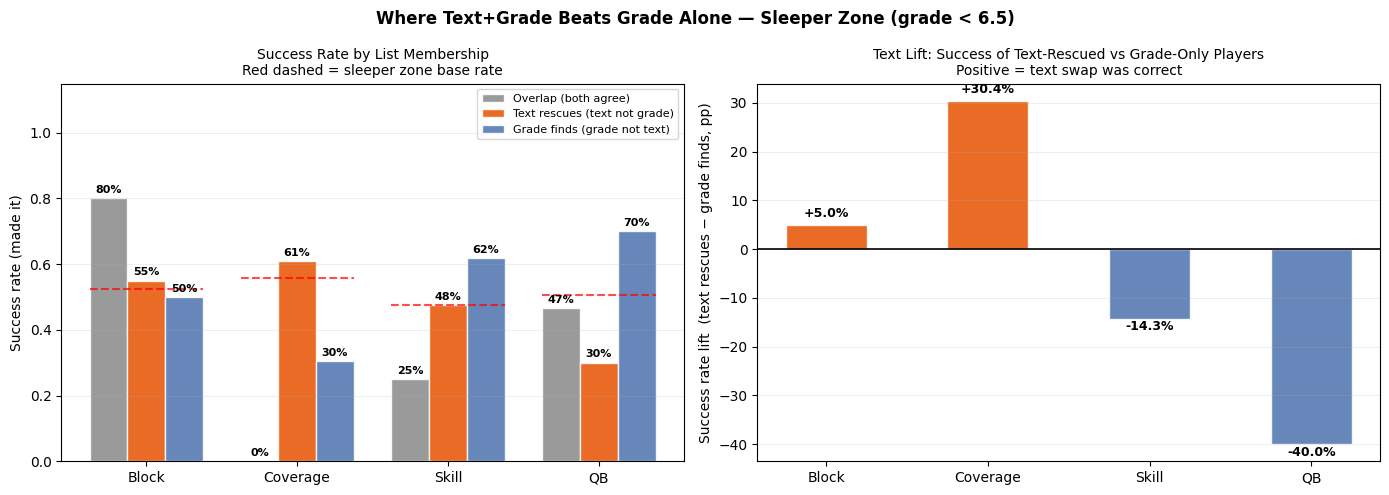

In [17]:

# ── Where does text+grade beat grade alone? ───────────────────────────────────
# Within the sleeper zone (grade < SLEEPER_GRADE):
#   Grade-only top-K   = ranked by base_score
#   Text+grade top-K   = ranked by text_score
#
# The two lists overlap but differ. Players unique to each list tell us:
#   "Text finds"  = text+grade top-K but NOT in grade-only top-K
#                   → these are players text rescued from outside the grade top-K
#   "Grade finds" = grade-only top-K but NOT in text+grade top-K
#                   → these are players text demoted below K
#
# If "Text finds" has higher precision than "Grade finds", text is adding value.

print(f"Sleeper Zone Delta Analysis  (grade < {SLEEPER_GRADE}, K = {K})")
print(f"Which players does text+grade find that grade alone misses — and are they right?")
print("=" * 72)

delta_records = []

for grp, (train_df, y, t_oof, b_oof) in ALL_GROUPS.items():
    sl_mask = train_df['grade'].values < SLEEPER_GRADE
    sl_df   = train_df[sl_mask][['player_name', 'Pos_Group', 'grade',
                                  'made_it_contract', 'year']].copy().reset_index(drop=True)
    sl_df['text_score'] = t_oof[sl_mask]
    sl_df['base_score'] = b_oof[sl_mask]
    y_sl = np.asarray(y)[sl_mask]

    # Top-K indices by each model
    text_top_idx  = set(sl_df.nlargest(K, 'text_score').index)
    grade_top_idx = set(sl_df.nlargest(K, 'base_score').index)

    overlap_idx    = text_top_idx & grade_top_idx          # both agree
    text_only_idx  = text_top_idx - grade_top_idx          # text finds, grade misses
    grade_only_idx = grade_top_idx - text_top_idx          # grade finds, text demotes

    def success_rate(idx):
        if not idx: return np.nan, 0
        vals = sl_df.loc[list(idx), 'made_it_contract'].astype(int).values
        return vals.mean(), len(vals)

    ov_rate,  ov_n  = success_rate(overlap_idx)
    tx_rate,  tx_n  = success_rate(text_only_idx)
    gr_rate,  gr_n  = success_rate(grade_only_idx)
    base_rate        = y_sl.mean()

    print(f"\n{grp}  (sleeper base rate = {base_rate:.1%})")
    print(f"  Overlap (both lists):        {ov_n:>3} players  →  {ov_rate:.1%} made it")
    print(f"  Text finds  (text not grade):{tx_n:>3} players  →  {tx_rate:.1%} made it  ← text adds these")
    print(f"  Grade finds (grade not text):{gr_n:>3} players  →  {gr_rate:.1%} made it  ← text removes these")
    lift = tx_rate - gr_rate if not (np.isnan(tx_rate) or np.isnan(gr_rate)) else np.nan
    print(f"  Text lift over demoted:      {lift:>+.1%}  (positive = text swap was correct)")

    delta_records.append(dict(
        Group=grp, Base_rate=base_rate,
        Overlap_n=ov_n,   Overlap_rate=ov_rate,
        Text_n=tx_n,      Text_rate=tx_rate,
        Grade_n=gr_n,     Grade_rate=gr_rate,
        Lift=lift,
    ))

    # ── Name the players text uniquely rescued ────────────────────────────────
    rescued = sl_df.loc[list(text_only_idx)].sort_values('text_score', ascending=False)
    demoted = sl_df.loc[list(grade_only_idx)].sort_values('base_score', ascending=False)
    print(f"\n  Players text rescues (not in grade top-{K}):")
    if len(rescued):
        print(rescued[['player_name','Pos_Group','grade','text_score',
                        'base_score','made_it_contract']].to_string(
                        index=False, float_format='{:.3f}'.format))
    print(f"\n  Players text demotes (dropped from grade top-{K}):")
    if len(demoted):
        print(demoted[['player_name','Pos_Group','grade','text_score',
                        'base_score','made_it_contract']].to_string(
                        index=False, float_format='{:.3f}'.format))

# ── Summary bar chart ─────────────────────────────────────────────────────────
delta_df = pd.DataFrame(delta_records).dropna(subset=['Text_rate', 'Grade_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: success rates of overlap / text-only / grade-only
ax = axes[0]
x  = np.arange(len(delta_df))
w  = 0.25
ax.bar(x - w,   delta_df['Overlap_rate'], width=w, color='#888888',
       label='Overlap (both agree)', alpha=0.85, edgecolor='white')
ax.bar(x,       delta_df['Text_rate'],    width=w, color='#E65100',
       label=f'Text rescues (text not grade)', alpha=0.85, edgecolor='white')
ax.bar(x + w,   delta_df['Grade_rate'],   width=w, color='#4C72B0',
       label=f'Grade finds (grade not text)', alpha=0.85, edgecolor='white')

for i, row in delta_df.iterrows():
    for val, offset in [(row['Overlap_rate'], -w),
                        (row['Text_rate'],     0),
                        (row['Grade_rate'],    w)]:
        if not np.isnan(val):
            ax.text(i + offset, val + 0.01, f'{val:.0%}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.plot([i - 1.5*w, i + 1.5*w], [row['Base_rate'], row['Base_rate']],
            color='red', lw=1.5, ls='--', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(delta_df['Group'], fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Success rate (made it)')
ax.set_title(f'Success Rate by List Membership\n'
             f'Red dashed = sleeper zone base rate', fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.2)

# Right: lift = text_rate - grade_rate
ax2 = axes[1]
colors_lift = ['#E65100' if v > 0 else '#4C72B0' for v in delta_df['Lift']]
bars = ax2.bar(x, delta_df['Lift'] * 100, color=colors_lift, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, val in zip(bars, delta_df['Lift']):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2,
             h + (1 if h >= 0 else -3),
             f'{val:+.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(0, color='black', lw=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(delta_df['Group'], fontsize=10)
ax2.set_ylabel('Success rate lift  (text rescues − grade finds, pp)')
ax2.set_title(f'Text Lift: Success of Text-Rescued vs Grade-Only Players\n'
              f'Positive = text swap was correct', fontsize=10)
ax2.grid(axis='y', alpha=0.2)

fig.suptitle(f'Where Text+Grade Beats Grade Alone — Sleeper Zone (grade < {SLEEPER_GRADE})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Sleeper Contract Analysis: Can text find UDFA-risk players who get signed?

**Reframed research question:** Among players scouts grade below 6.0 (UDFA / very late round risk), can scouting text identify which ones actually get signed to an NFL contract?

- **Sleeper zone:** grade < 6.0 — scouts think these players are borderline undraftable
- **Outcome:** `made_it_contract` — got any NFL contract (drafted *or* signed as UDFA)
- **Base rate:** ~17–18% within grade < 6.0 (vs ~50% for `is_drafted` at grade < 6.5)
- **Models are refit fresh** on this outcome within the sleeper zone only


In [18]:

# ── Cell 1: Build sleeper zone datasets with made_it_contract outcome ─────────
from sklearn.model_selection import StratifiedKFold, KFold

SLEEPER_GRADE = 6.0
K_EVAL = 25
#updated from 25 to 20 - did not work; also no dice for 30

# made_it_contract lives on df (raw load) but was not the training target.
# Merge it back using the original df index, restricted to training years.
contract_series = (
    df.loc[df.year.between(2014, 2021), 'made_it_contract']
    .map({True: 1, False: 0, 1: 1, 0: 0})  # handle bool or int
)

def build_sleeper_group(train_df):
    """
    Filter a position group's training df to grade < SLEEPER_GRADE,
    attach made_it_contract, drop rows with unknown outcome.
    Returns (sub_df, y) or (None, None) if too small.
    """
    sub = train_df[train_df['grade'] < SLEEPER_GRADE].copy()
    sub = sub.join(contract_series.rename('contract'), how='left')
    sub = sub.dropna(subset=['contract'])
    sub['contract'] = sub['contract'].astype(int)
    y = sub['contract']
    return sub, y

SLEEPER_GROUPS = {}
print(f"Sleeper zone  (grade < {SLEEPER_GRADE})  —  made_it_contract outcome")
print(f"{'Group':<10}  {'N':>5}  {'Positives':>10}  {'Base rate':>10}")
print("-" * 42)

for grp, train_df in [('Block',    block_train),
                       ('Coverage', coverage_train),
                       ('Skill',    skill_train),
                       ('QB',       qb_train)]:
    sub, y = build_sleeper_group(train_df)
    if sub is None or len(sub) < K_EVAL or y.sum() < 5:
        print(f"{grp:<10}  — too few positives, skipping —")
        continue
    SLEEPER_GROUPS[grp] = (sub, y)
    print(f"{grp:<10}  {len(sub):>5}  {int(y.sum()):>10}  {y.mean():>10.1%}")


Sleeper zone  (grade < 6.0)  —  made_it_contract outcome
Group           N   Positives   Base rate
------------------------------------------
Block         539         129       23.9%
Coverage      870         224       25.7%
Skill         670         105       15.7%
QB             94          13       13.8%


In [19]:

# ── Cell 2: Refit models on made_it_contract within sleeper zone + evaluate ───
# Models are trained fresh here — NOT reusing is_drafted OOF scores.
# Use StratifiedKFold where possible; fall back to KFold if too few positives/fold.

from sklearn.metrics import average_precision_score

def safe_cv(y, n_splits=5):
    """Use StratifiedKFold unless any fold would have < 2 positives."""
    n_pos = int(y.sum())
    if n_pos >= n_splits * 2:
        return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    return KFold(n_splits=min(n_splits, n_pos), shuffle=True, random_state=42)

def prec_rec_at_k(y_true, scores, k):
    y_arr = np.asarray(y_true)
    idx   = np.argsort(scores)[::-1][:min(k, len(y_arr))]
    prec  = y_arr[idx].mean()
    rec   = y_arr[idx].sum() / max(y_arr.sum(), 1)
    return prec, rec

CONTRACT_RESULTS = {}

print(f"Sleeper zone (grade < {SLEEPER_GRADE}) — made_it_contract OOF evaluation")
print(f"{'Group':<10}  {'Base%':>6}  "
      f"{'── Grade only ──':^30}  {'── Text+Grade ──':^30}")
print(f"{'':10}  {'':6}  "
      f"{'Prec@25':>9}  {'Rec@25':>8}  {'PR-AUC':>9}  "
      f"{'Prec@25':>9}  {'Rec@25':>8}  {'PR-AUC':>9}")
print("-" * 80)

for grp, (sub, y) in SLEEPER_GROUPS.items():
    cv_grp = safe_cv(y)

    # Grade-only OOF
    b_oof = cross_val_predict(
        make_baseline_pipe(), sub[['grade', 'Pos_Group']], y,
        cv=cv_grp, method='predict_proba'
    )[:, 1]

    # Text+grade OOF
    t_oof = cross_val_predict(
        make_full_pipe(), sub, y,
        cv=cv_grp, method='predict_proba'
    )[:, 1]

    base_rate   = y.mean()
    b_prec, b_rec = prec_rec_at_k(y, b_oof, K_EVAL)
    t_prec, t_rec = prec_rec_at_k(y, t_oof, K_EVAL)
    b_prauc       = average_precision_score(y, b_oof)
    t_prauc       = average_precision_score(y, t_oof)

    CONTRACT_RESULTS[grp] = dict(
        sub=sub, y=y, b_oof=b_oof, t_oof=t_oof,
        base_rate=base_rate,
        b_prec=b_prec, b_rec=b_rec, b_prauc=b_prauc,
        t_prec=t_prec, t_rec=t_rec, t_prauc=t_prauc,
    )

    print(f"{grp:<10}  {base_rate:>6.1%}  "
          f"{b_prec:>9.1%}  {b_rec:>8.1%}  {b_prauc:>9.4f}  "
          f"{t_prec:>9.1%}  {t_rec:>8.1%}  {t_prauc:>9.4f}")

print(f"\nBase rate ~17% means Prec@25 > 30% is meaningful lift over random selection.")


Sleeper zone (grade < 6.0) — made_it_contract OOF evaluation
Group        Base%         ── Grade only ──                ── Text+Grade ──       
                      Prec@25    Rec@25     PR-AUC    Prec@25    Rec@25     PR-AUC
--------------------------------------------------------------------------------
Block        23.9%      24.0%      4.7%     0.2909      48.0%      9.3%     0.3178
Coverage     25.7%      28.0%      3.1%     0.3410      36.0%      4.0%     0.3223
Skill        15.7%      16.0%      3.8%     0.1901      28.0%      6.7%     0.1946
QB           13.8%      32.0%     61.5%     0.2573      24.0%     46.2%     0.2861

Base rate ~17% means Prec@25 > 30% is meaningful lift over random selection.


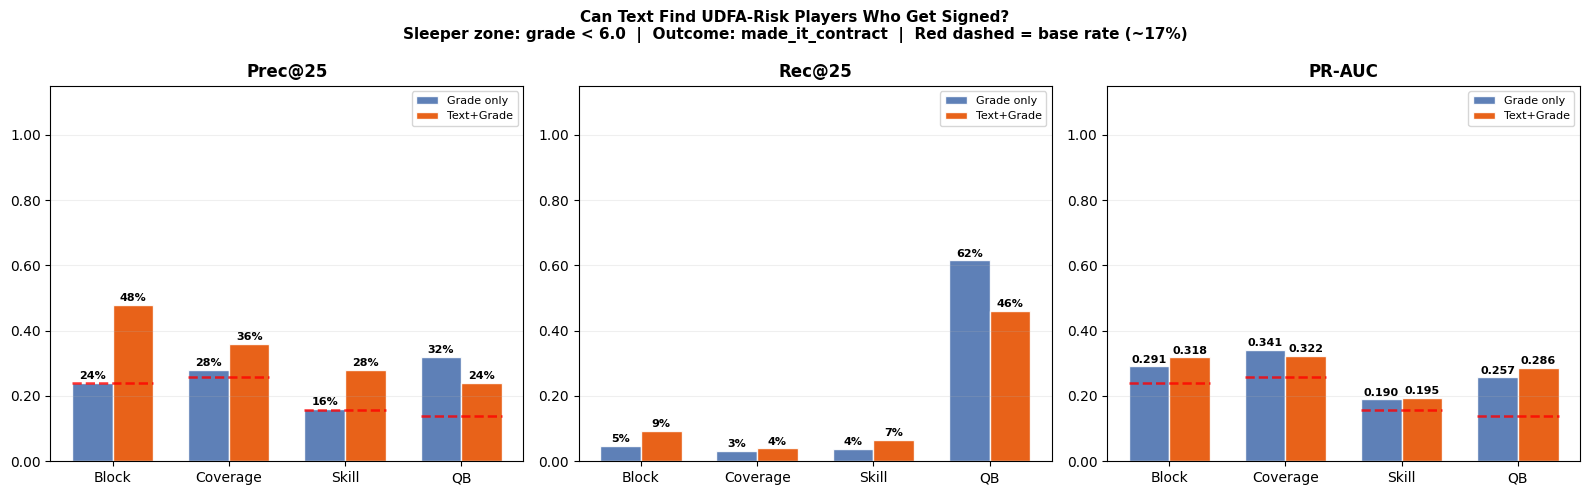

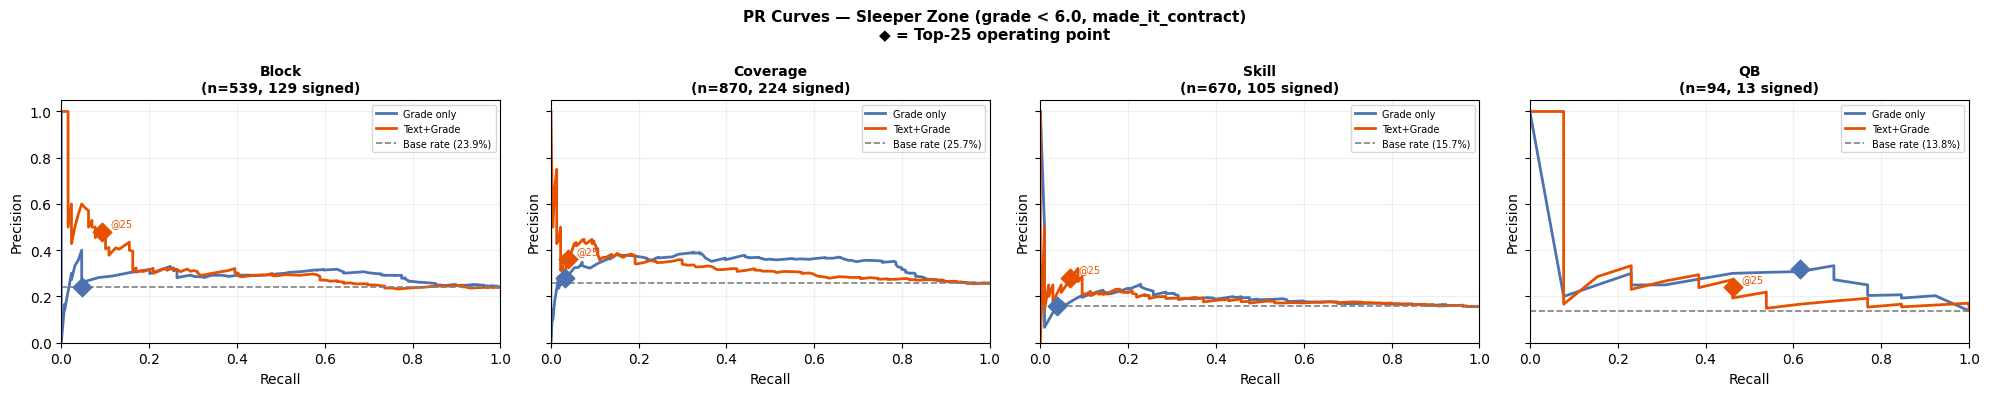

In [20]:

# ── Cell 3: Bar chart + PR curves ────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

COLOR_BASE = '#4C72B0'
COLOR_TEXT = '#E65100'

res_df = pd.DataFrame([
    dict(Group=g, Base_rate=v['base_rate'],
         Base_Prec=v['b_prec'], Base_Rec=v['b_rec'], Base_PRAUC=v['b_prauc'],
         Text_Prec=v['t_prec'], Text_Rec=v['t_rec'], Text_PRAUC=v['t_prauc'])
    for g, v in CONTRACT_RESULTS.items()
])

# ── Grouped bars ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('Prec@25', 'Base_Prec', 'Text_Prec', True),
           ('Rec@25',  'Base_Rec',  'Text_Rec',  False),
           ('PR-AUC',  'Base_PRAUC','Text_PRAUC', True)]

for ax, (label, bc, tc, show_br) in zip(axes, metrics):
    x, w = np.arange(len(res_df)), 0.35
    b_bars = ax.bar(x - w/2, res_df[bc], width=w, color=COLOR_BASE, alpha=0.9,
                    label='Grade only', edgecolor='white')
    t_bars = ax.bar(x + w/2, res_df[tc], width=w, color=COLOR_TEXT, alpha=0.9,
                    label='Text+Grade', edgecolor='white')
    for bar in list(b_bars) + list(t_bars):
        h = bar.get_height()
        fmt = f'{h:.0%}' if label != 'PR-AUC' else f'{h:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                fmt, ha='center', va='bottom', fontsize=8, fontweight='bold')
    if show_br:
        for i, row in res_df.iterrows():
            ax.plot([i - w, i + w], [row['Base_rate'], row['Base_rate']],
                    color='red', lw=1.8, ls='--', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(res_df['Group'], fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}' if label != 'PR-AUC' else f'{v:.2f}'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

fig.suptitle(f'Can Text Find UDFA-Risk Players Who Get Signed?\n'
             f'Sleeper zone: grade < {SLEEPER_GRADE}  |  Outcome: made_it_contract  |  '
             f'Red dashed = base rate (~17%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── PR curves ─────────────────────────────────────────────────────────────────
n = len(CONTRACT_RESULTS)
fig2, axes2 = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1: axes2 = [axes2]

for ax, (grp, v) in zip(axes2, CONTRACT_RESULTS.items()):
    for scores, color, lbl in [(v['b_oof'], COLOR_BASE, 'Grade only'),
                                (v['t_oof'], COLOR_TEXT,  'Text+Grade')]:
        p_c, r_c, _ = precision_recall_curve(v['y'], scores)
        ax.plot(r_c, p_c, color=color, lw=2, label=lbl)
    ax.axhline(v['base_rate'], color='grey', ls='--', lw=1.2,
               label=f"Base rate ({v['base_rate']:.1%})")
    # mark @K operating points
    for scores, color, pk, rk in [(v['b_oof'], COLOR_BASE, v['b_prec'], v['b_rec']),
                                   (v['t_oof'], COLOR_TEXT,  v['t_prec'], v['t_rec'])]:
        ax.scatter([rk], [pk], color=color, s=90, zorder=5, marker='D')
    ax.annotate(f'@{K_EVAL}', xy=(v['t_rec'], v['t_prec']),
                xytext=(6, 4), textcoords='offset points', fontsize=7, color=COLOR_TEXT)
    ax.set_title(f"{grp}\n(n={len(v['sub'])}, {int(v['y'].sum())} signed)",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=7); ax.grid(alpha=0.2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

fig2.suptitle(f'PR Curves — Sleeper Zone (grade < {SLEEPER_GRADE}, made_it_contract)\n'
              f'◆ = Top-{K_EVAL} operating point',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


Delta Analysis — grade < 6.0, outcome: made_it_contract, K=25

Block  (base rate = 23.9%)
  Overlap (both lists):           0  →  nan% signed
  Text rescues (text, not grade): 25  →  48.0% signed  ← text adds
  Grade finds  (grade, not text): 25  →  32.0% signed  ← text removes
  Lift: +16.0%  ✓ text swap correct

  Text rescues (not in grade top-25):
        player_name Pos_Group  grade  text_score  base_score  contract
       Morgan Moses        OL  5.800       0.600       0.674         1
   Charles Leno Jr.        OL  5.800       0.573       0.654         1
        Josh Walker        OL  5.600       0.560       0.447         0
        Niles Scott        DT  5.500       0.530       0.576         0
       Trey Hopkins        OL  5.500       0.522       0.465         1
      Tyler Orlosky        OL  5.900       0.520       0.555         0
      Dakota Dozier        OL  5.900       0.515       0.555         0
Rakeem Nunez-Roches        DT  5.600       0.505       0.581         1
       

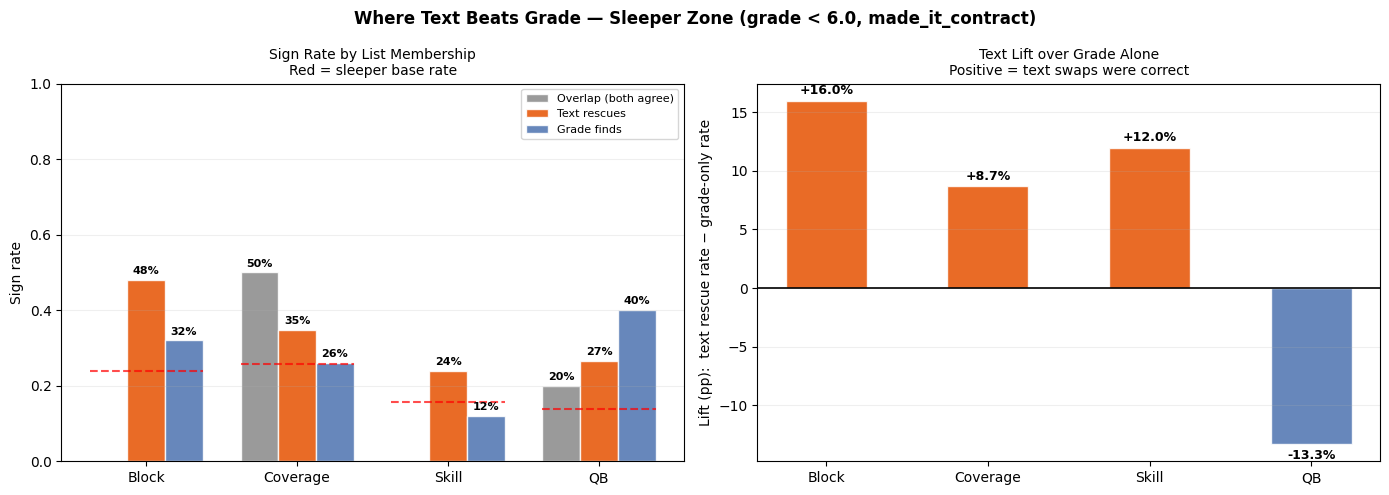

In [21]:

# ── Cell 4: Delta analysis — where does text beat grade? ─────────────────────
# Top-K by text+grade vs top-K by grade-only within the sleeper zone.
# "Text rescues" = in text top-K but not grade top-K → did they get signed?
# "Grade finds"  = in grade top-K but not text top-K → did they get signed?
# Lift = text rescue rate − grade-only rate (positive = text swap was correct)

print(f"Delta Analysis — grade < {SLEEPER_GRADE}, outcome: made_it_contract, K={K_EVAL}")
print("=" * 70)

delta_records = []

for grp, v in CONTRACT_RESULTS.items():
    sub, y = v['sub'], v['y']
    t_oof, b_oof = v['t_oof'], v['b_oof']
    base_rate = v['base_rate']

    sl = sub[['player_name', 'Pos_Group', 'grade', 'contract', 'year']].copy().reset_index(drop=True)
    sl['text_score'] = t_oof
    sl['base_score'] = b_oof

    text_top  = set(sl.nlargest(K_EVAL, 'text_score').index)
    grade_top = set(sl.nlargest(K_EVAL, 'base_score').index)

    overlap_idx    = text_top & grade_top
    text_only_idx  = text_top - grade_top
    grade_only_idx = grade_top - text_top

    def sr(idx):
        if not idx: return np.nan, 0
        vals = sl.loc[list(idx), 'contract'].values
        return vals.mean(), len(vals)

    ov_r, ov_n = sr(overlap_idx)
    tx_r, tx_n = sr(text_only_idx)
    gr_r, gr_n = sr(grade_only_idx)
    lift = tx_r - gr_r if not (np.isnan(tx_r) or np.isnan(gr_r)) else np.nan

    print(f"\n{grp}  (base rate = {base_rate:.1%})")
    print(f"  Overlap (both lists):         {ov_n:>3}  →  {ov_r:.1%} signed")
    print(f"  Text rescues (text, not grade):{tx_n:>3}  →  {tx_r:.1%} signed  ← text adds")
    print(f"  Grade finds  (grade, not text):{gr_n:>3}  →  {gr_r:.1%} signed  ← text removes")
    print(f"  Lift: {lift:+.1%}  {'✓ text swap correct' if lift > 0 else '✗ text swap incorrect'}")

    delta_records.append(dict(Group=grp, Base_rate=base_rate,
                              Overlap_n=ov_n, Overlap_rate=ov_r,
                              Text_n=tx_n,    Text_rate=tx_r,
                              Grade_n=gr_n,   Grade_rate=gr_r,
                              Lift=lift))

    rescued = sl.loc[list(text_only_idx)].sort_values('text_score', ascending=False)
    demoted = sl.loc[list(grade_only_idx)].sort_values('base_score', ascending=False)

    print(f"\n  Text rescues (not in grade top-{K_EVAL}):")
    print(rescued[['player_name','Pos_Group','grade','text_score','base_score','contract']]
          .to_string(index=False, float_format='{:.3f}'.format))

    print(f"\n  Grade finds (dropped by text):")
    print(demoted[['player_name','Pos_Group','grade','text_score','base_score','contract']]
          .to_string(index=False, float_format='{:.3f}'.format))

# ── Summary chart ─────────────────────────────────────────────────────────────
delta_df = pd.DataFrame(delta_records).dropna(subset=['Text_rate', 'Grade_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x, w = np.arange(len(delta_df)), 0.25
ax.bar(x - w,   delta_df['Overlap_rate'], width=w, color='#888888',
       label='Overlap (both agree)', alpha=0.85, edgecolor='white')
ax.bar(x,       delta_df['Text_rate'],    width=w, color=COLOR_TEXT,
       label='Text rescues', alpha=0.85, edgecolor='white')
ax.bar(x + w,   delta_df['Grade_rate'],   width=w, color=COLOR_BASE,
       label='Grade finds', alpha=0.85, edgecolor='white')
for i, row in delta_df.iterrows():
    for val, off in [(row['Overlap_rate'], -w), (row['Text_rate'], 0), (row['Grade_rate'], w)]:
        if not np.isnan(val):
            ax.text(i + off, val + 0.01, f'{val:.0%}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.plot([i - 1.5*w, i + 1.5*w], [row['Base_rate'], row['Base_rate']],
            color='red', lw=1.5, ls='--', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(delta_df['Group'], fontsize=10)
ax.set_ylim(0, 1.0); ax.set_ylabel('Sign rate')
ax.set_title('Sign Rate by List Membership\nRed = sleeper base rate', fontsize=10)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

ax2 = axes[1]
colors_lift = [COLOR_TEXT if v > 0 else COLOR_BASE for v in delta_df['Lift']]
bars = ax2.bar(np.arange(len(delta_df)), delta_df['Lift'] * 100,
               color=colors_lift, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, delta_df['Lift']):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + (0.3 if h >= 0 else -1.5),
             f'{val:+.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(0, color='black', lw=1.2)
ax2.set_xticks(np.arange(len(delta_df)))
ax2.set_xticklabels(delta_df['Group'], fontsize=10)
ax2.set_ylabel('Lift (pp):  text rescue rate − grade-only rate')
ax2.set_title('Text Lift over Grade Alone\nPositive = text swaps were correct', fontsize=10)
ax2.grid(axis='y', alpha=0.2)

fig.suptitle(f'Where Text Beats Grade — Sleeper Zone (grade < {SLEEPER_GRADE}, made_it_contract)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [22]:
from scipy.stats import fisher_exact
from scipy.stats import permutation_test

def rescue_vs_find(grp_name, res):
    sub    = res['sub'].copy()
    y      = res['y'].values
    b_oof  = res['b_oof']
    t_oof  = res['t_oof']

    top_k       = min(K_EVAL, len(y))
    b_idx       = set(np.argsort(b_oof)[::-1][:top_k])
    t_idx       = set(np.argsort(t_oof)[::-1][:top_k])

    rescue_idx  = np.array(list(t_idx - b_idx))
    find_idx    = np.array(list(b_idx - t_idx))
    overlap_idx = np.array(list(t_idx & b_idx))

    groups = {'Text Rescue': rescue_idx, 'Grade Find': find_idx, 'Overlap': overlap_idx}
    groups = {k: v for k, v in groups.items() if len(v) > 0}

    print(f"\n{'='*55}")
    print(f"  {grp_name} — contract rate by selection group")
    print(f"{'='*55}")
    for name, idx in groups.items():
        print(f"  {name:<15}  N={len(idx):>3}  contract_rate={y[idx].mean():.1%}")

    # ── Fisher's Exact (primary): Text Rescue vs Grade Find ───────────────────
    if 'Text Rescue' not in groups or 'Grade Find' not in groups:
        print("  Missing Rescue or Find group — skipping tests.")
        return

    r = y[groups['Text Rescue']]
    g = y[groups['Grade Find']]

    if len(r) < 2 or len(g) < 2:
        print("  Too few observations for testing — skipping.")
        return

    table = np.array([
        [r.sum(),   len(r) - r.sum()],
        [g.sum(),   len(g) - g.sum()],
    ])
    odds_ratio, p_fisher = fisher_exact(table, alternative='greater')
    print(f"\n  Fisher's Exact (Rescue vs Find):")
    print(f"    Contingency table:")
    print(f"                  Signed  Not Signed")
    print(f"    Text Rescue   {int(table[0,0]):>6}  {int(table[0,1]):>10}")
    print(f"    Grade Find    {int(table[1,0]):>6}  {int(table[1,1]):>10}")
    print(f"    Odds ratio={odds_ratio:.3f},  p={p_fisher:.4f}  ", end='')
    print("(Rescues sign more often)" if p_fisher < 0.05 else "(no significant difference)")

    # ── Permutation test (robustness check) ───────────────────────────────────
    def stat_fn(a, b, axis):
        return np.mean(a, axis=axis) - np.mean(b, axis=axis)

    perm = permutation_test(
        (r, g),
        stat_fn, vectorized=True, n_resamples=9999,
        alternative='greater', random_state=42
    )
    print(f"  Permutation test (Rescue > Find):  p={perm.pvalue:.4f}")

for grp_name, res in CONTRACT_RESULTS.items():
    rescue_vs_find(grp_name, res)


  Block — contract rate by selection group
  Text Rescue      N= 25  contract_rate=48.0%
  Grade Find       N= 25  contract_rate=24.0%

  Fisher's Exact (Rescue vs Find):
    Contingency table:
                  Signed  Not Signed
    Text Rescue       12          13
    Grade Find         6          19
    Odds ratio=2.923,  p=0.0699  (no significant difference)
  Permutation test (Rescue > Find):  p=0.0712

  Coverage — contract rate by selection group
  Text Rescue      N= 23  contract_rate=34.8%
  Grade Find       N= 23  contract_rate=26.1%
  Overlap          N=  2  contract_rate=50.0%

  Fisher's Exact (Rescue vs Find):
    Contingency table:
                  Signed  Not Signed
    Text Rescue        8          15
    Grade Find         6          17
    Odds ratio=1.511,  p=0.3747  (no significant difference)
  Permutation test (Rescue > Find):  p=0.3825

  Skill — contract rate by selection group
  Text Rescue      N= 25  contract_rate=28.0%
  Grade Find       N= 25  contract_